In [92]:
import numpy as np
import math
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
def savepkl(obj, path):
    with open(path, 'wb') as f:
        pickle.dump(obj, f)

def loadpkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)
import pyreadr 
import sys
import os
sys.path.append(os.path.abspath(".."))
from mpl_toolkits.mplot3d import Axes3D
from ripser import ripser
from persim import plot_diagrams
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import gridspec

def deco_pd(ax,diagrams,colors,markers,title,size=None,title_size=None,ticks=False,plot_only=None):
    # 1) plotting - origninal diagram
    plot_diagrams(diagrams,plot_only=plot_only, ax=ax, size=50)
    points = []
    for p in ax.collections:
        arr = p.get_offsets()
        for xy in arr:
            points.append(tuple(xy))
    x_max, y_max = max(points, key=lambda t: t[1])
    # 2) removing each points from the original diagram
    for artist in ax.collections[:]:
        artist.remove()
    # -------------------------------
    # no points in the diagram 
    # but diagonal line 
    # ------------------------------
    for i, diag in enumerate(diagrams):
        if type(diag)==int or len(diag) == 0:
            continue
        births = diag[:, 0]
        deaths = diag[:, 1]
    
        ax.scatter(
            births, deaths,
            s=size,
            marker=markers.get(i, "o"),
            color=colors.get(i, "black"),
            label=f"$H_{i}$"
        )
        if i==0:
            ax.scatter(x_max,y_max,s=size,marker=markers.get(i, "o"),
            color=colors.get(i, "black"))
    
    ax.set_title(title,fontsize=title_size)
    if title_size:
        ax.legend(fontsize=title_size-3,loc="lower right")
    else:
        ax.legend(fontsize=12,loc="lower right")
    if not ticks: 
        ax.set_xticks([])
        ax.set_yticks([])
        
def plot_persistence_intensity(
    PD_list,
    filename,
    title,
    title_size=16,
    grid_size=300,
    bandwidth=0.005,
    alpha=1.0,
    levels=100,
    cmap="viridis"
):
    """
    Estimate and visualize persistence intensity function.

    Parameters
    ----------
    PD_list : list of array, where each array is shape of (N, 2): Persistence diagram (birth, death).
    xlim, ylim : tuple, optional
        Plot ranges (min, max). If None, inferred from PD.
    grid_size : int
        Number of grid points per axis.
    bandwidth : float
        Gaussian kernel bandwidth.
    levels : int
        Number of contour levels.
    cmap : str
        Matplotlib colormap.

    Returns
    -------
    intensity : 2D ndarray
        Estimated intensity values.
    """
    colors = [
    '#ffffff',  
    '#253494'
            ]

    custom_cmap = LinearSegmentedColormap.from_list(
        'white_to_blue',
    colors,
    N=256
    )
    min_=np.inf
    max_=-np.inf
    for PD in PD_list: 
        min_= np.min([min_,PD[:, 0].min()])
        max_=np.max([max_,PD[:, 1].max()])

    xlim = (min_, max_)
    ylim = (min_, max_)

    grid_x = np.linspace(xlim[0], xlim[1], grid_size)
    grid_y = np.linspace(ylim[0], ylim[1], grid_size)
    X, Y = np.meshgrid(grid_x, grid_y, indexing="ij")
    
    # -------------------------
    # Intensity estimation
    # -------------------------
    intensity = np.zeros_like(X)
    for PD in PD_list:
        for k in range(PD.shape[0]):
            dx = X - PD[k, 0]
            dy = Y - PD[k, 1]
            intensity +=  np.exp(
                -(dx**2 + dy**2) / (2 * bandwidth**2)
            )
    intensity /= (len(PD_list) * np.sqrt(2 * np.pi * bandwidth**2)) 
    intensity[Y < X] = 0.0
    
    # -------------------------
    # Visualization
    # -------------------------
    fig = plt.figure(figsize=(16, 5))
    gs = gridspec.GridSpec(
    1, 4,
    width_ratios=[1, 1, 1, 1.4],  # intensity를 조금 더 넓게
    wspace=0.25
     )

    # -------------------------
    # Left: persistence diagrams
    # -------------------------
    markers = {0: "^", 1: "o"}
    colors  = {0: "#a1dab4", 1: "#225ea8"}
    axs_pd = [fig.add_subplot(gs[0, i]) for i in range(3)]
    
    for i, ax in enumerate(axs_pd):
        deco_pd(ax=ax,diagrams=[1,PD_list[i]],colors=colors,markers=markers,size=8,title_size=title_size,plot_only=[1],ticks=False,
                title=f'Persistence diagram {i+1}')
         
    # -------------------------
    # Right: intensity function
    # -------------------------
    ax_int = fig.add_subplot(gs[0, 3])

    plot_diagrams([1,PD_list[i]],plot_only=[1], ax=ax_int,legend=False)
    # removing each points from the original diagram
    for artist in ax_int.collections[:]:
        artist.remove()
        
    cf = ax_int.contourf(
    X, Y, intensity,
    levels=levels,
    cmap=custom_cmap
    )
    
    ax_int.set_title(title, fontsize=title_size)
    ax_int.set_xticks([])
    ax_int.set_yticks([])
    ax_int.set_box_aspect(1)

    
    cbar = fig.colorbar(cf, ax=ax_int, shrink=0.70)
    cbar.set_ticks([0])
    cbar.set_ticklabels(["0"])
    cbar.set_label("")
    cbar.ax.text(
    0.5, 1.02, "High",
    ha="center",
    va="bottom",
    transform=cbar.ax.transAxes,
    fontsize=title_size-1
    )
    
    # -------------------------
    # Layout
    # -------------------------
    plt.tight_layout()
    # fig.canvas.draw()
    
    # pos_A = axs_pd[0].get_position()
    # pos_B = ax_int.get_position()
    
    # # 두 축 중 더 높은 위치를 기준으로 공통 y좌표 설정
    # label_y = max(pos_A.y1, pos_B.y1) + 0.015
    
    # # A
    # fig.text(
    #     pos_A.x0 - 0.015,
    #     label_y,
    #     "A",
    #     fontsize=25,
    #     fontweight="bold",
    #     ha="left",
    #     va="bottom"
    # )
    
    # # B
    # fig.text(
    #     pos_B.x0 - 0.015,
    #     label_y,
    #     "B",
    #     fontsize=25,
    #     fontweight="bold",
    #     ha="left",
    #     va="bottom"
    # )
    
    # -------------------------
    # Save
    # -------------------------
    fig.savefig(
        f"results/figures/figure_file/{filename}.png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.05
    )
    
    fig.savefig(
        f"results/figures/figure_file/{filename}.pdf",
        bbox_inches="tight",
        pad_inches=0.05
    )
    
    plt.show()

IndentationError: unexpected indent (2277602765.py, line 14)

In [213]:
def simulation_to_latex_table(
    noise_levels,
    Bonf_result, PI_result, PD_result, PL_result,
    weight_dictionary,
    caption1="Test comparison", caption2="Weight comparison",
    label1="tab:test_comp", label2="tab:weight_comp"
):
    # Helper for formatting values (0.001 → <0.001)
    def fmt(x):
        return "<0.001" if x < 0.001 else f"{x:.3f}"

    latex = []

    # ===============================
    # 1) Bonf / PI / PD / PL comparision
    # ===============================
    latex.append("\\begin{table}[H]")
    latex.append("\\centering")
    latex.append(f"\\caption{{{caption1}}}")
    latex.append(f"\\label{{{label1}}}")

    cols = " & ".join([f"${nl}$" for nl in noise_levels])
    latex.append(f"\\begin{{tabular}}{{l{'c' * len(noise_levels)}}}")
    latex.append("\\toprule")
    latex.append(r"Method\$\sigma$ & " + cols + " \\\\")
    latex.append("\\midrule")

    # Rows
    latex.append("Bonf test & " + " & ".join(fmt(x) for x in Bonf_result) + " \\\\")
    latex.append("PI test & " + " & ".join(fmt(x) for x in PI_result) + " \\\\")
    latex.append("PD test & " + " & ".join(fmt(x) for x in PD_result) + " \\\\")
    latex.append("PL test & " + " & ".join(fmt(x) for x in PL_result) + " \\\\")
    latex.append("\\bottomrule")
    latex.append("\\end{tabular}")
    latex.append("\\end{table}")
    latex.append("\n")

    # ===============================
    # 2) Weight function comparision
    # ===============================
    latex.append("\\begin{table}[H]")
    latex.append("\\centering")
    latex.append(f"\\caption{{{caption2}}}")
    latex.append(f"\\label{{{label2}}}")

    latex.append(f"\\begin{{tabular}}{{l{'c' * len(noise_levels)}}}")
    latex.append("\\toprule")
    latex.append(r"Weight\$\sigma$ & " + cols + " \\\\")
    latex.append("\\midrule")
    
    # Rows
    for key, values in weight_dictionary.items():
        latex.append(f"{key} & " + " & ".join(fmt(x) for x in values) + " \\\\")
    latex.append("\\bottomrule")
    latex.append("\\end{tabular}")
    latex.append("\\end{table}")

    return "\n".join(latex)


# Orbit5k Data

In [51]:
file_list = [
    "data/orbit_data/orbit5k_X_original_00.npy",
    "data/orbit_data/orbit5k_X_original_05.npy",
    "data/orbit_data/orbit5k_X_original_10.npy",
    "data/orbit_data/orbit5k_X_original_15.npy",
    "data/orbit_data/orbit5k_X_original_20.npy",
    "data/orbit_data/orbit5k_X_original_25.npy",
    "data/orbit_data/orbit5k_X_original_30.npy",
    "data/orbit_data/orbit5k_X_original_35.npy",
]
arrays = [np.load(f) for f in file_list]
X = np.stack(arrays, axis=0)
y = np.load("data/orbit_data/orbit5k_y.npy")
X_r1 = X[:,np.where(y==0)[0],:,:]
X_r2 = X[:,np.where(y==2)[0],:,:]
X_r3 = X[:,np.where(y==4)[0],:,:]

In [52]:
PD_r1 = loadpkl('data/orbit_data/PD_r1.pkl')
PD_r2 = loadpkl('data/orbit_data/PD_r2.pkl')
PD_r3 = loadpkl('data/orbit_data/PD_r3.pkl')

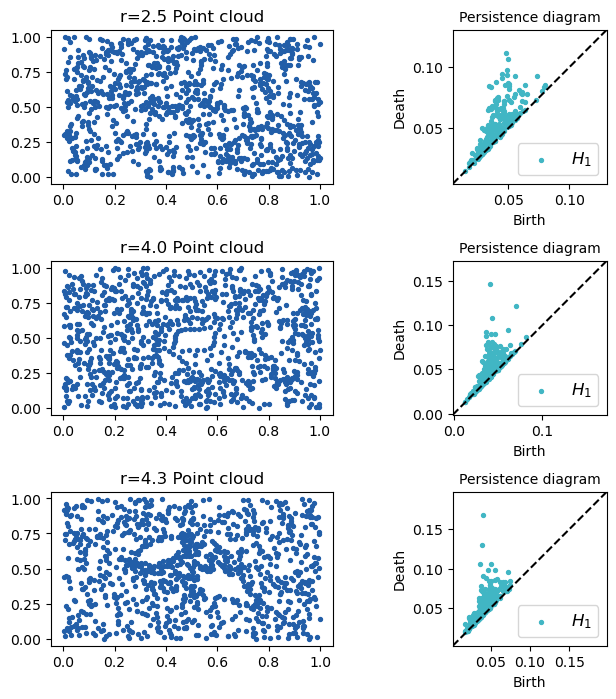

In [68]:
markers = {0: "^", 1: "o"}
colors  = {0:"#225ea8", 1: "#41b6c4"}
fig, axes = plt.subplots(3, 2, figsize=(8, 8))


axes[0,0].scatter(X_r1[0][0][:,0],X_r1[0][0][:,1],s=8,color=colors[0])
axes[0,0].set_title("r=2.5 Point cloud")
deco_pd(ax=axes[0,1],diagrams=[1,PD_r1[0][0]],colors=colors,markers=markers,size=8,plot_only=[1],ticks=True,title='Persistence diagram')


axes[1,0].scatter(X_r2[0][0][:,0],X_r2[0][0][:,1],s=8,color=colors[0])
axes[1,0].set_title("r=4.0 Point cloud")

# plot_diagrams([1,PD_r2[0][0]], plot_only=[1],ax=axes[1,1], title=None, xy_range=None, show=False)
# axes[1,1].set_title("Persistence Diagram")
deco_pd(ax=axes[1,1],diagrams=[1,PD_r2[0][0]],colors=colors,markers=markers,size=8,plot_only=[1],ticks=True,title='Persistence diagram')


axes[2,0].scatter(X_r3[0][0][:,0],X_r3[0][0][:,1],s=8,color=colors[0])
axes[2,0].set_title("r=4.3 Point cloud")

deco_pd(ax=axes[2,1],diagrams=[1,PD_r3[0][0]],colors=colors,markers=markers,size=8,plot_only=[1],ticks=True,title='Persistence diagram')


fig.subplots_adjust(hspace=0.50)
plt.savefig(
    "results/figures/figure_file/Orbit.pdf",
    #bbox_inches="tight",
    pad_inches=1
)

plt.show() 

# Musical Instruments

In [71]:
N=60
flute = [pd.read_csv(f"data/flute_diagrams/flute_onedim_{i}.csv").to_numpy() for i in range(1, N+1)]
clarinet = [pd.read_csv(f"data/clarinet_diagrams/clarinet_onedim_{i}.csv").to_numpy() for i in range(1, N+1)]

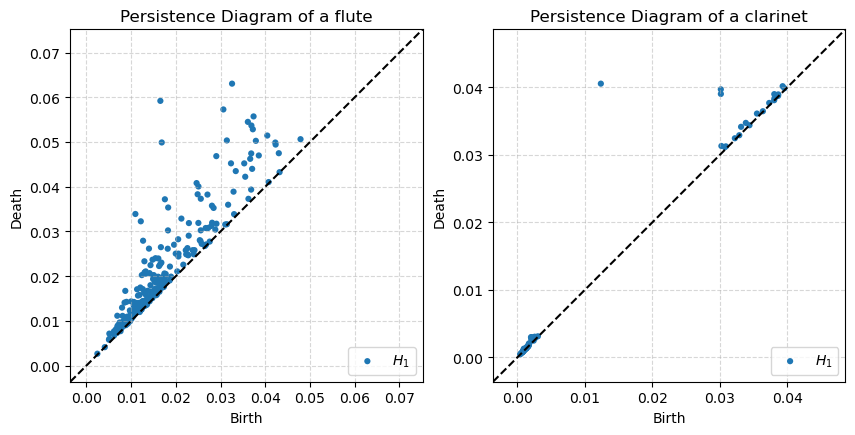

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1행 2열
# PD1
plot_diagrams([1,flute[0]], plot_only=[1],ax=axes[0], title=None, xy_range=None, show=False)
axes[0].set_title("Persistence Diagram of a flute", fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.5)

# PD2
plot_diagrams([1,clarinet[0]], plot_only=[1],ax=axes[1], title=None, xy_range=None, show=False)
axes[1].set_title("Persistence Diagram of a clarinet", fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.5)

# fig.tight_layout(rect=[0, 0, 1, 0.88])
# fig.canvas.draw()

# for ax, label in zip(axes, ["A", "B"]):
#     pos = ax.get_position()

#     fig.text(
#         pos.x0,
#         pos.y1 + 0.075,
#         label,
#         fontsize=25,
#         fontweight="bold",
#         ha="left",
#         va="top"      
#     )

fig.savefig(
    "results/figures/figure_file/PDsofsounds.pdf",
    dpi=300
)

plt.show()


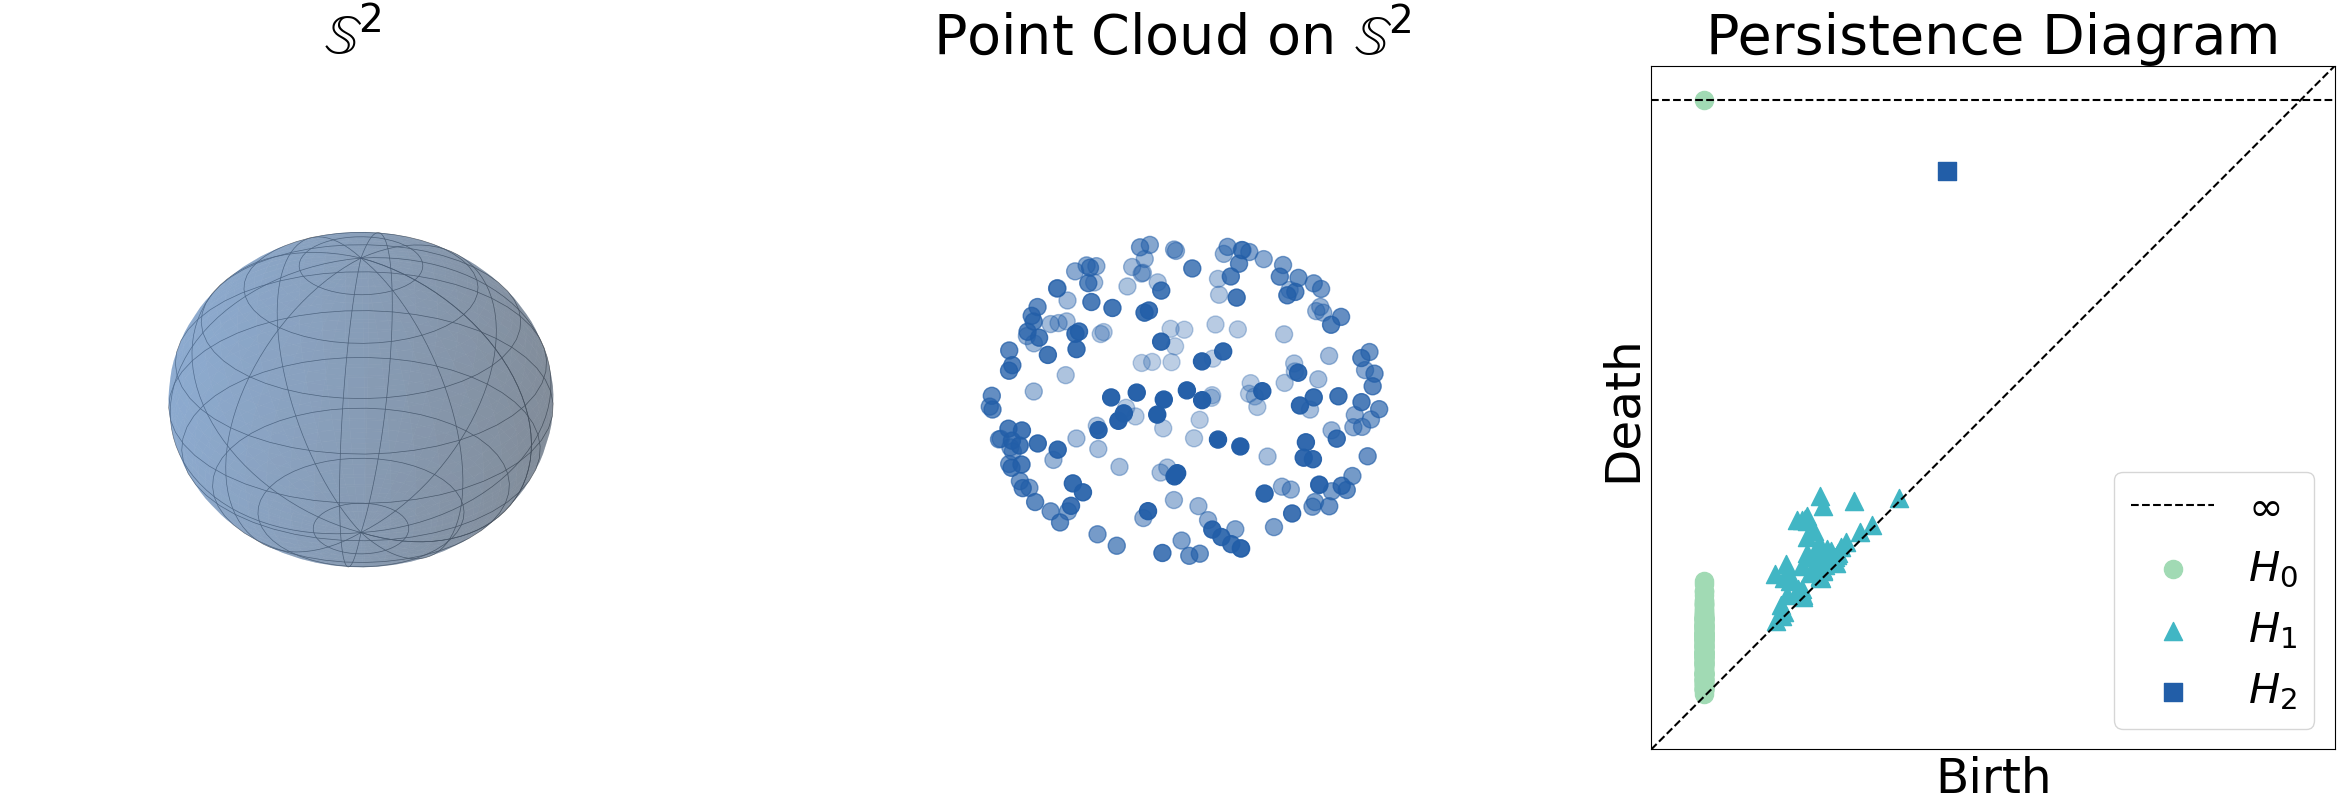

In [3]:
def sample_sphere(n_points):
    phi = np.random.uniform(0, 2*np.pi, n_points)
    cos_theta = np.random.uniform(-1, 1, n_points)
    theta = np.arccos(cos_theta)
    x = np.sin(theta)*np.cos(phi)
    y = np.sin(theta)*np.sin(phi)
    z = np.cos(theta)
    return np.vstack([x, y, z]).T

n_points = 200
X = sample_sphere(n_points)

diagrams = ripser(X, maxdim=2)['dgms']

fig = plt.figure(figsize=(30, 12))

# --- left: S^2 ---
ax1 = fig.add_subplot(1,3,1, projection='3d')
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 50)
x_s = np.outer(np.cos(u), np.sin(v))
y_s = np.outer(np.sin(u), np.sin(v))
z_s = np.outer(np.ones(np.size(u)), np.cos(v))
ax1.plot_surface(x_s, y_s, z_s, color='#225ea8', alpha=0.3, edgecolor='none')
ax1.plot_wireframe(x_s, y_s, z_s, color='gray', linewidth=0.5, rstride=5, cstride=5)
ax1.set_title(r'$\mathbb{S}^2$', fontsize=40)
ax1.set_xticks(np.arange(-1, 1.1, 0.5))
ax1.set_yticks(np.arange(-1, 1.1, 0.5))
ax1.set_zticks(np.arange(-1, 1.1, 0.5))
ax1.axis('off')

# --- middle: point cloud ---
ax2 = fig.add_subplot(1,3,2, projection='3d')
ax2.scatter(X[:,0], X[:,1], X[:,2], color='#225ea8', s=150)
ax2.set_title(r'Point Cloud on $\mathbb{S}^2$', fontsize=40)
ax2.set_xticks(np.arange(-1, 1.1, 0.5))
ax2.set_yticks(np.arange(-1, 1.1, 0.5))
ax2.set_zticks(np.arange(-1, 1.1, 0.5))
ax2.axis('off')

# --- right: persistence diagram ---
ax3 = fig.add_subplot(1, 3, 3)

# 1) plotting - origninal diagram
plot_diagrams(diagrams, ax=ax3, show=False, size=170)
points = []
for p in ax3.collections:
    arr = p.get_offsets()
    for xy in arr:
        points.append(tuple(xy))

# y_max
x_max, y_max = max(points, key=lambda t: t[1])


for artist in ax3.collections[:]:
    artist.remove()

# -------------------------------
# no points in the diagram 
# but diagonal line 
# -------------------------------

markers = {0: "o", 1: "^", 2: "s"}
colors  = {0: "#a1dab4", 1: "#41b6c4", 2: "#225ea8"}

for i, diag in enumerate(diagrams):
    if len(diag) == 0:
        continue
    births = diag[:, 0]
    deaths = diag[:, 1]

    ax3.scatter(
        births, deaths,
        s=170,
        marker=markers.get(i, "o"),
        color=colors.get(i, "black"),
        label=f"$H_{i}$"
    )
    if i==0:
        ax3.scatter(x_max,y_max,s=170,marker=markers.get(i, "o"),
        color=colors.get(i, "black"))

ax3.set_title("Persistence Diagram", fontsize=40)
ax3.set_xlabel("Birth", fontsize=35)
ax3.set_ylabel("Death", fontsize=35)
ax3.set_xticks([])
ax3.set_yticks([])
ax3.legend(fontsize=30)

# plt.tight_layout(rect=[0, 0, 1, 0.88])
# # tight_layout 이후 확정된 각 패널의 위치
# for ax, label in zip([ax1, ax2, ax3], ["A", "B", "C"]):
#     pos = ax.get_position()

#     fig.text(
#         pos.x0 - 0.015,   # 패널 왼쪽보다 약간 왼쪽
#         pos.y1 + 0.015,   # 패널 위쪽보다 약간 위
#         label,
#         fontsize=60,
#         fontweight="bold",
#         ha="left",
#         va="bottom"
#     )

plt.savefig(
    "results/figures/figure_file/pdexample.pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.20
)
plt.show()


## Torus

In [5]:
def Poisson_homo_torus(lam,R,r):
    """
    :param lam: intensity per unit area on torus surface
    :param R: major radius
    :param r: minor radius
    reference: "Sampling from a manifold." by Persi Diaconis and TDA R-package's torusUnif function
    """
    total_intensity = 4*math.pi**2*R*r
    n=np.random.poisson(lam*total_intensity)
    theta =np.array([])
    while len(theta)<n:
        xvec= np.random.uniform(0,2*math.pi,1)
        yvec= np.random.uniform(0,1/math.pi,1)
        fx= (1+ (r/R)*np.cos(xvec))/(2*math.pi)
        if yvec <fx :
            theta=np.append(theta,xvec)
    phi=np.random.uniform(0,2*math.pi,n)
    x = (R+ r*np.cos(theta))*np.cos(phi)
    y = (R+ r*np.cos(theta))*np.sin(phi)
    z = r*np.sin(theta)
    return np.column_stack((x,y,z))

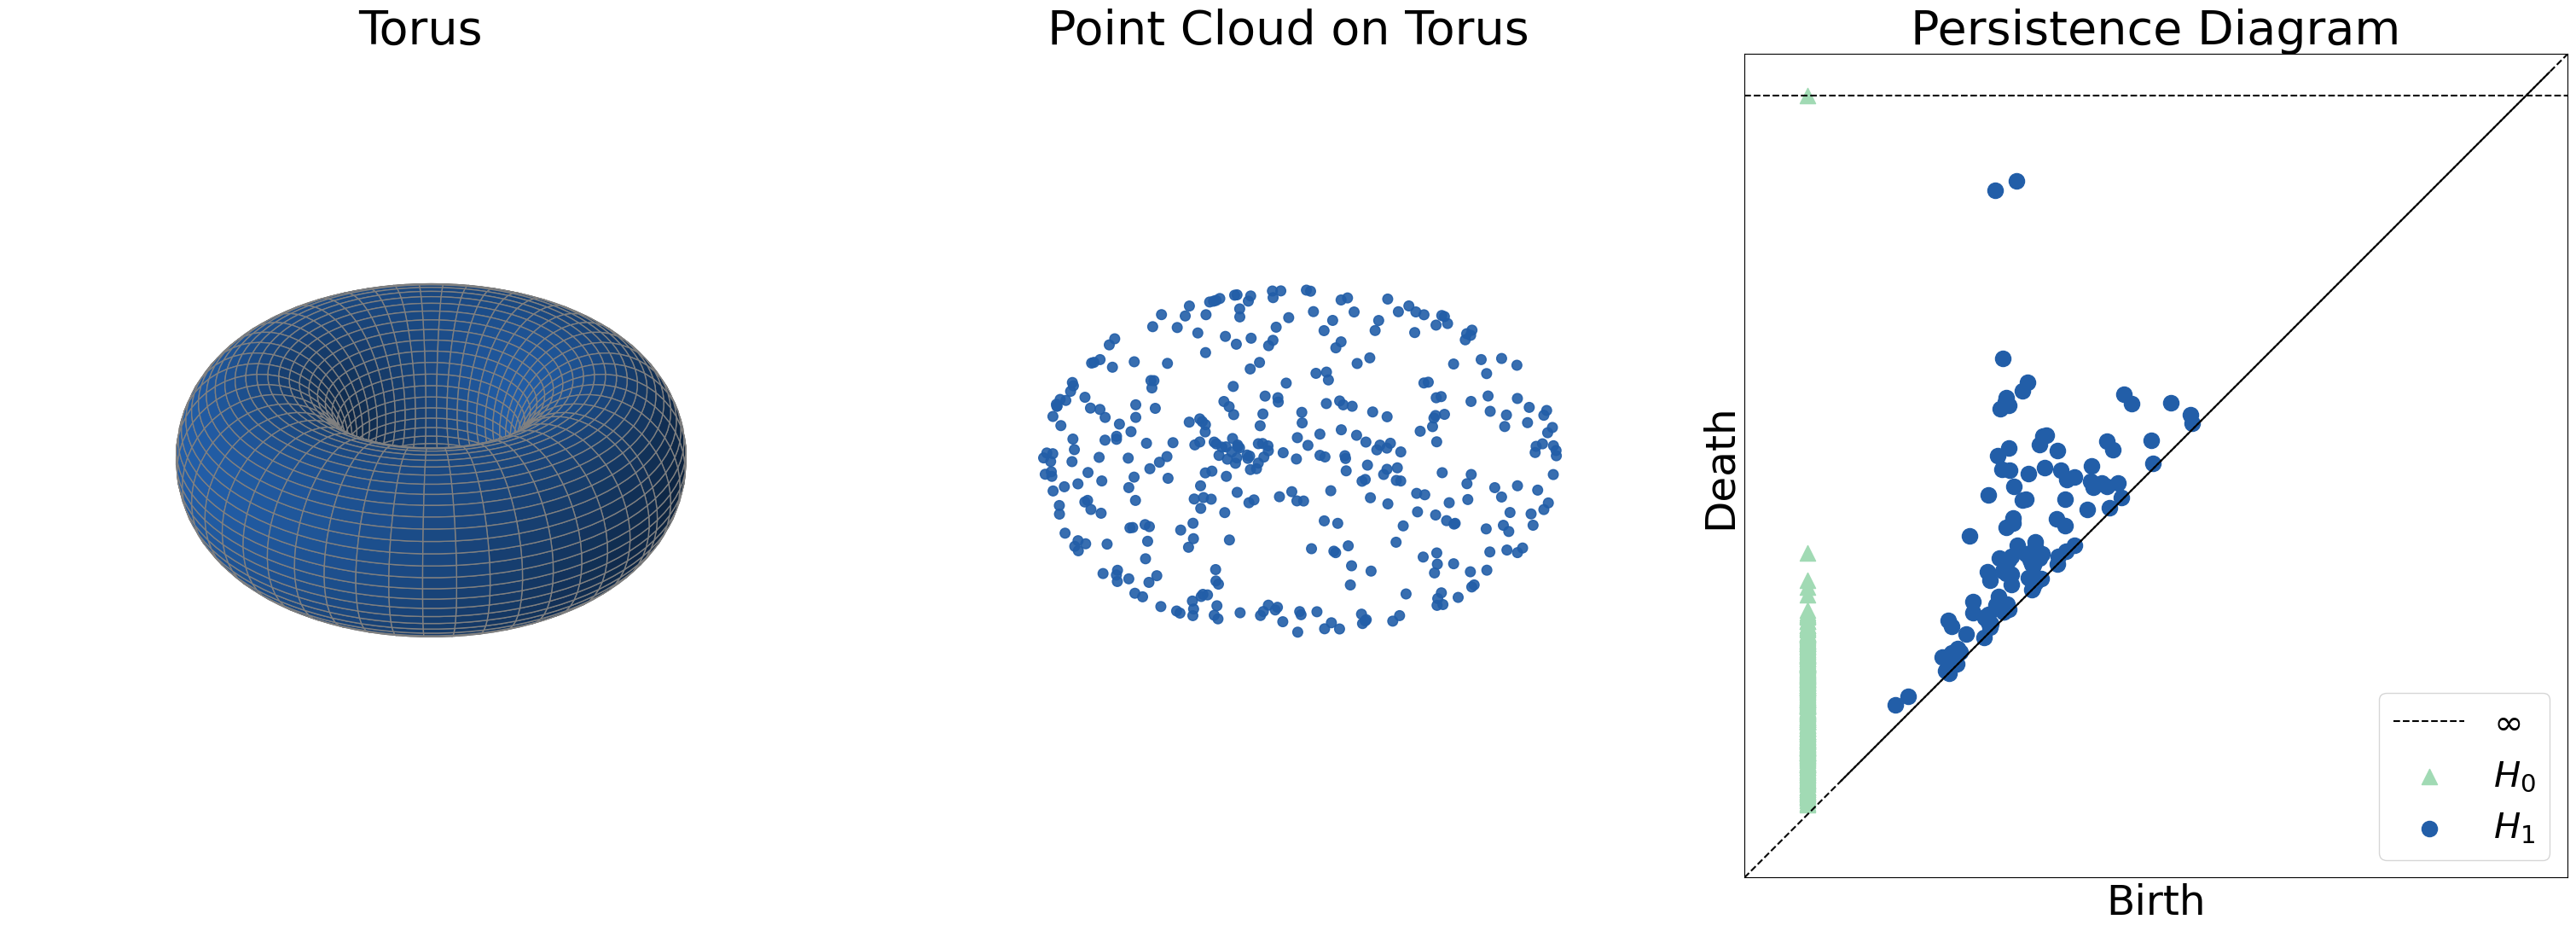

In [6]:
# Parameters for the torus
R = 2  # Major radius
r = 1  # Minor radius

# Create a meshgrid for u (angle around the main circle) and v (angle around the tube)
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, 2 * np.pi, 50)
u, v = np.meshgrid(u, v)

# Parametric equations for the torus
x = (R + r * np.cos(v)) * np.cos(u)
y = (R + r * np.cos(v)) * np.sin(u)
z = r * np.sin(v)

Data =Poisson_homo_torus(5,R,r)
xs, ys, zs = Data[:,0], Data[:,1], Data[:,2]
diagrams = ripser(Data, maxdim=1)['dgms']


fig = plt.figure(figsize=(30, 12))


ax1 = fig.add_subplot(1,3,1, projection='3d')
ax1.plot_surface(x, y, z, color='#225ea8', edgecolor='gray', alpha=1)
#ax1.plot_wireframe(x_s, y_s, z_s, color='gray', linewidth=0.5, rstride=5, cstride=5)
ax1.set_title('Torus', fontsize=40)


# --- middle: point cloud ---
ax2 = fig.add_subplot(1,3,2, projection='3d')
ax2.scatter(xs, ys, zs, color='#225ea8', s=70, alpha=0.9)
ax2.set_title('Point Cloud on Torus', fontsize=40)
ax2.set_xticks(np.arange(-1, 1.1, 0.5))
ax2.set_yticks(np.arange(-1, 1.1, 0.5))
ax2.set_zticks(np.arange(-1, 1.1, 0.5))

# --- right: persistence diagram ---
ax3 = fig.add_subplot(1,3,3)
plot_diagrams(diagrams,  plot_only=[1],ax=ax3, show=False, size=200)
# 1) plotting - origninal diagram
plot_diagrams(diagrams, ax=ax3, show=False, size=170)
points = []
for p in ax3.collections:
    arr = p.get_offsets()
    for xy in arr:
        points.append(tuple(xy))

# y_max
x_max, y_max = max(points, key=lambda t: t[1])



# 2) removing each points from the original diagram

for artist in ax3.collections[:]:
    artist.remove()

# -------------------------------
# no points in the diagram 
# but diagonal line 
# -------------------------------

markers = {0: "^", 1: "o"}
colors  = {0: "#a1dab4", 1: "#225ea8"}

for i, diag in enumerate(diagrams):
    if len(diag) == 0:
        continue
    births = diag[:, 0]
    deaths = diag[:, 1]

    ax3.scatter(
        births, deaths,
        s=170,
        marker=markers.get(i, "o"),
        color=colors.get(i, "black"),
        label=f"$H_{i}$"
    )
    if i==0:
        ax3.scatter(x_max,y_max,s=170,marker=markers.get(i, "o"),
        color=colors.get(i, "black"))


ax3.set_title('Persistence Diagram', fontsize=40)
ax3.set_xlabel('Birth', fontsize=35)
ax3.set_ylabel('Death', fontsize=35)
legend = ax3.legend(fontsize=30)
ax3.set_xticks([])
ax3.set_yticks([])
# Set aspect and remove axes
ax1.set_box_aspect([1+R/r, 1+R/r, 1])
ax1.axis('off')
ax2.set_box_aspect([1+R/r, 1+R/r, 1])    
ax2.axis('off')

plt.tight_layout(pad=0)
plt.savefig('results/figures/figure_file/Torus_example.pdf',
             dpi=600, bbox_inches='tight')
plt.show()


In [11]:
np.random.seed(42)
R = 2  # Major radius
r = 1  # Minor radius
diagram_list=[]
N=3
for _ in range(N):
    Data =Poisson_homo_torus(5,R,r)
    diagram_list.append(ripser(Data, maxdim=1)['dgms'][1])

/var/folders/l8/x4_rg_g96h3bqtgtpq_bycvh0000gn/T/ipykernel_38448/813402051.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


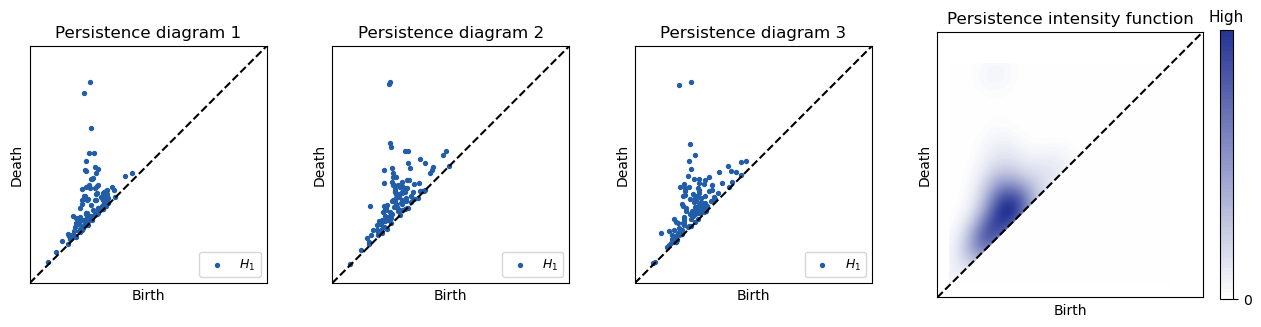

In [12]:
plot_persistence_intensity(diagram_list,filename='Intensity_function_example',title='Persistence intensity function',title_size=12,bandwidth=0.1) 

## Torus-Empirical power

### Varying shifting scale

In [216]:
PD_result = loadpkl('results/simulation_results/Torus_results/torus_radius_pd_summary.pkl')['rejection_rate']
PL_result = loadpkl('results/simulation_results/Torus_results/torus_radius_pl_summary.pkl')['rejection_rate']
Bonf_result = loadpkl('results/simulation_results/Torus_results/torus_radius_bonferroni_square_summary.pkl')['rejection_rate']
result = pyreadr.read_r("results/simulation_results/Torus_results/Torus_PI_power_result.rds")
PI_result = np.array(result[None]).reshape(-1) # pandas Series/DataFrame 

Bonf_result_constant= loadpkl('results/simulation_results/Torus_results/torus_radius_bonferroni_constant_summary.pkl')['rejection_rate']
Bonf_result_linear = loadpkl('results/simulation_results/Torus_results/torus_radius_bonferroni_linear_summary.pkl')['rejection_rate']
Bonf_result_square = loadpkl('results/simulation_results/Torus_results/torus_radius_bonferroni_square_summary.pkl')['rejection_rate']

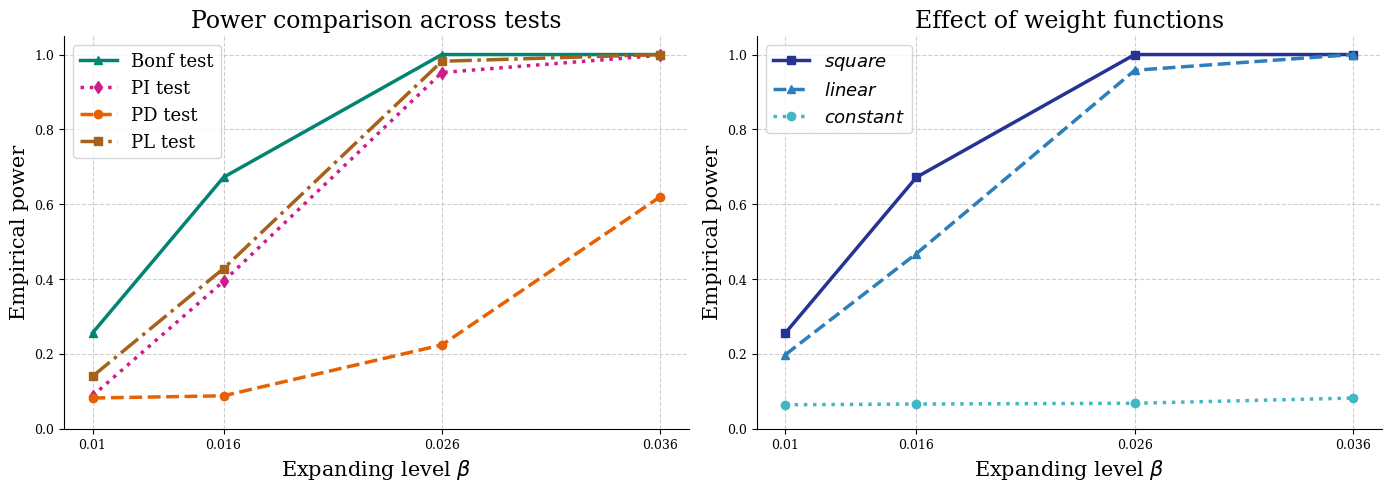

In [217]:
shifting_levels =  np.array([0.01, 0.016, 0.026, 0.036])
colors=['#018571','#d01c8b','#e66101','#a6611a']
fig, axes = plt.subplots(1, 2, figsize=(14,5))  # 1 row, 2 columns
colors2 = ['#253494','#2c7fb8','#41b6c4','#7fcdbb','#2ca25f']
# --- Left plot: Comparison across tests ---
axes[0].plot(shifting_levels, Bonf_result, marker='^', label="Bonf test",linestyle='-',color=colors[0], lw=2.5)
axes[0].plot(shifting_levels, PI_result, marker='d', label="PI test",linestyle=':',color=colors[1], lw=2.5)
axes[0].plot(shifting_levels, PD_result, marker='o', label="PD test",linestyle='--',color=colors[2], lw=2.5)
axes[0].plot(shifting_levels, PL_result, marker='s', label="PL test",linestyle='-.',color=colors[3], lw=2.5)
axes[0].set_xlabel(r"Expanding level $\beta$",fontsize=15)
axes[0].set_ylabel("Empirical power",fontsize=15)
axes[0].set_title("Power comparison across tests",fontsize=17)
axes[0].set_ylim(0,1.05)
axes[0].set_xticks(shifting_levels, [str(x) for x in shifting_levels])
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend(fontsize=13)

# --- Right plot: Effect of weight functions ---

axes[1].plot(shifting_levels, Bonf_result_square,
             marker='s', linestyle='-', label=r"$square$", color=colors2[0], lw=2.5)

axes[1].plot(shifting_levels, Bonf_result_linear,
             marker='^', linestyle='--', label=r"$linear$", color=colors2[1], lw=2.5)


axes[1].plot(shifting_levels, Bonf_result_constant,
             marker='o', linestyle=':', label=r"$constant$", color=colors2[2], lw=2.5)

axes[1].set_xlabel(r"Expanding level $\beta$",fontsize=15)
axes[1].set_ylabel("Empirical power",fontsize=15)
axes[1].set_title("Effect of weight functions",fontsize=17)
axes[1].set_ylim(0,1.05)
axes[1].set_xticks(shifting_levels, [str(x) for x in shifting_levels])
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend(fontsize=13,title_fontsize=12)

plt.tight_layout()
# fig.canvas.draw()

# # Panel labels
# for ax, label in zip(axes, ["A", "B"]):
#     pos = ax.get_position()

#     fig.text(
#         pos.x0 - 0.015,
#         pos.y1 + 0.015,
#         label,
#         fontsize=25,
#         fontweight="bold",
#         ha="left",
#         va="bottom"
#     )

plt.savefig("results/figures/figure_file/Torus_Simulation.png", dpi=300)
plt.savefig("results/figures/figure_file/Torus_Simulation.pdf")
plt.show()


In [218]:
latex_code = simulation_to_latex_table(
    shifting_levels,
    Bonf_result, PI_result, PD_result, PL_result,
    weight_dictionary={'$(y-x)^{2}$':Bonf_result_square,
        '$y-x$':Bonf_result_linear,
                       'constant':Bonf_result_constant
                        }
)

print(latex_code)


\begin{table}[H]
\centering
\caption{Test comparison}
\label{tab:test_comp}
\begin{tabular}{lcccc}
\toprule
Method\$\sigma$ & $0.01$ & $0.016$ & $0.026$ & $0.036$ \\
\midrule
Bonf test & 0.256 & 0.672 & 1.000 & 1.000 \\
PI test & 0.088 & 0.394 & 0.952 & 0.998 \\
PD test & 0.082 & 0.088 & 0.224 & 0.620 \\
PL test & 0.140 & 0.428 & 0.982 & 1.000 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}[H]
\centering
\caption{Weight comparison}
\label{tab:weight_comp}
\begin{tabular}{lcccc}
\toprule
Weight\$\sigma$ & $0.01$ & $0.016$ & $0.026$ & $0.036$ \\
\midrule
$(y-x)^{2}$ & 0.256 & 0.672 & 1.000 & 1.000 \\
$y-x$ & 0.198 & 0.468 & 0.958 & 1.000 \\
constant & 0.064 & 0.066 & 0.068 & 0.082 \\
\bottomrule
\end{tabular}
\end{table}


### Varying sample size

In [268]:
FIGURE_DIR = 'results/figures/figure_file/'
NSET = 500
RADIUS_SHIFTS = np.array([0.01, 0.016, 0.026, 0.036, 0.0])
alternative_indices = [
    index
    for index, shift in enumerate(RADIUS_SHIFTS)
    if shift > 0.0
]
alternative_shifts = RADIUS_SHIFTS[alternative_indices]

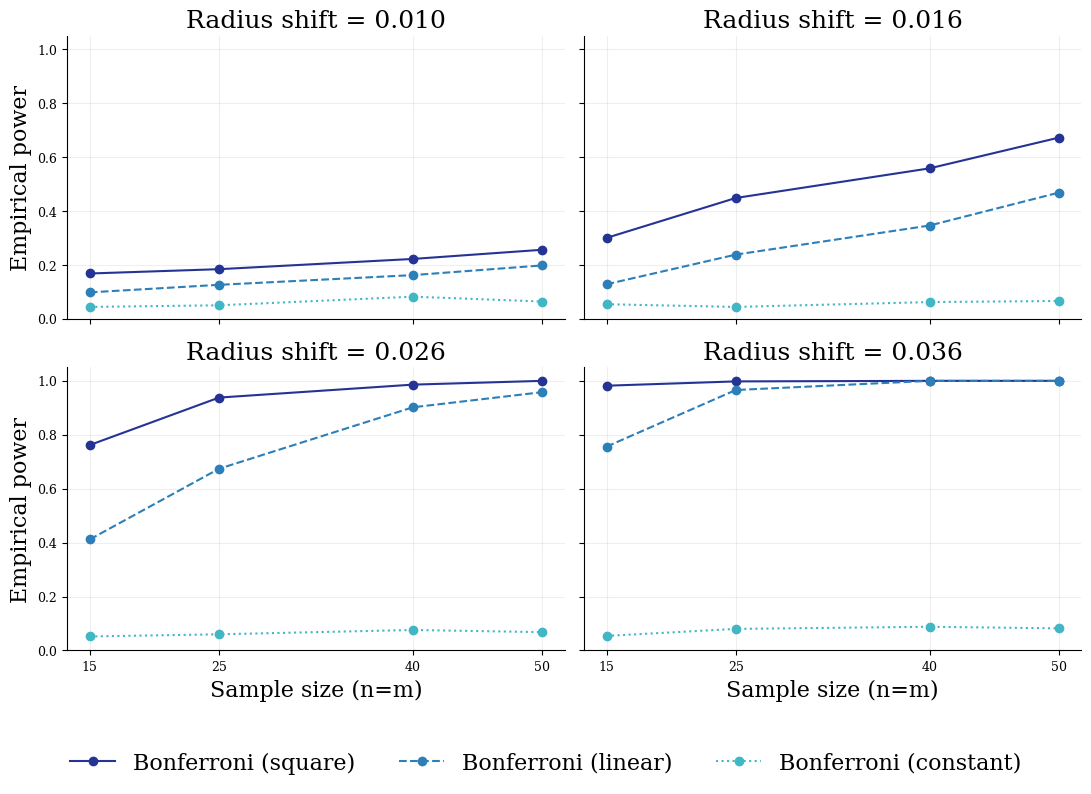

Saved: results/figures/figure_file/torus_radius_power_by_sample_size_weights.pdf


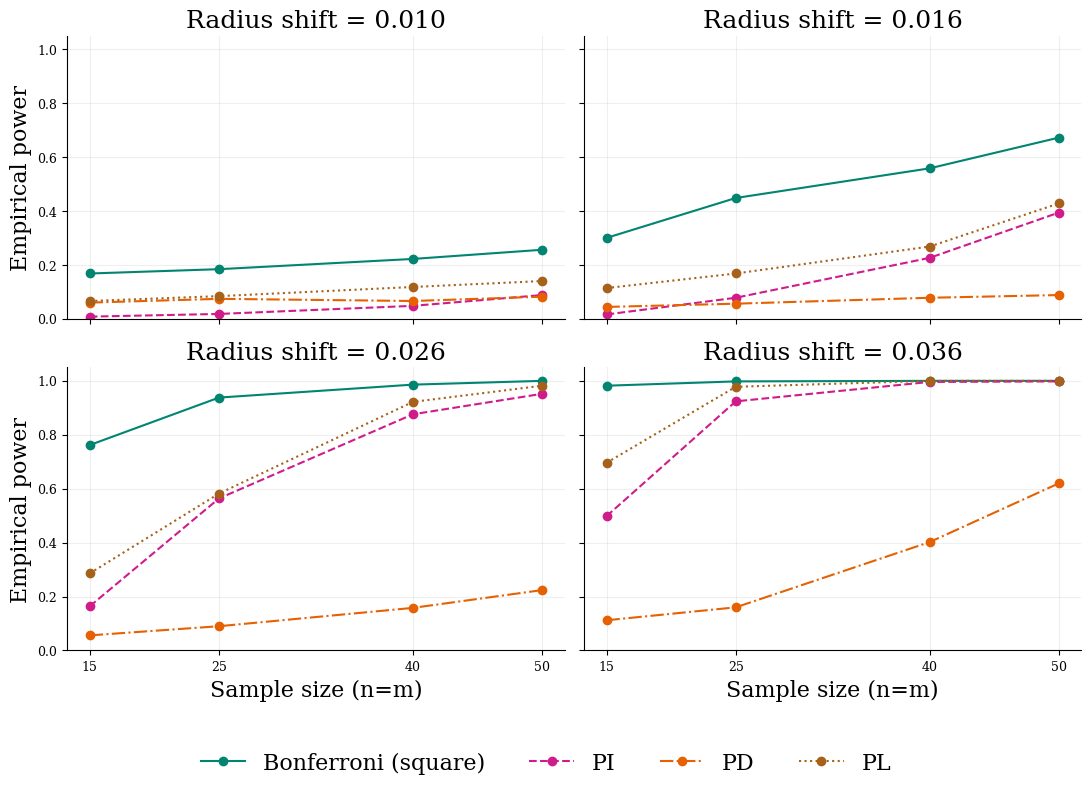

Saved: results/figures/figure_file/torus_radius_power_by_sample_size.pdf

Radius shift = 0.010


method,Bonferroni (square),Bonferroni (linear),Bonferroni (constant),PI,PD,PL
n=m,,,,,,
15,0.168,0.098,0.044,0.008,0.060,0.066
25,0.184,0.126,0.050,0.018,0.074,0.084
40,0.222,0.162,0.082,0.048,0.066,0.118
50,0.256,0.198,0.064,0.088,0.082,0.140


\begin{table}[t]
\centering
\caption{Empirical power at radius shift $\delta=0.010$, based on 500 replications. PI uses $C=0.2$.}
\label{tab:torus-power-shift-010}
\footnotesize
\setlength{\tabcolsep}{2pt}
\begin{tabular}{@{}rcccccc@{}}
\toprule
$n=m$ & Bonf$_{\mathrm{sq}}$ & Bonf$_{\mathrm{lin}}$ & Bonf$_{\mathrm{const}}$ & PI & PD & PL \\
\midrule
15 & 0.168 & 0.098 & 0.044 & 0.008 & 0.060 & 0.066 \\
25 & 0.184 & 0.126 & 0.050 & 0.018 & 0.074 & 0.084 \\
40 & 0.222 & 0.162 & 0.082 & 0.048 & 0.066 & 0.118 \\
50 & 0.256 & 0.198 & 0.064 & 0.088 & 0.082 & 0.140 \\
\bottomrule
\end{tabular}
\end{table}


Radius shift = 0.016


method,Bonferroni (square),Bonferroni (linear),Bonferroni (constant),PI,PD,PL
n=m,,,,,,
15,0.300,0.128,0.054,0.016,0.044,0.114
25,0.448,0.238,0.044,0.078,0.056,0.168
40,0.558,0.346,0.062,0.226,0.078,0.268
50,0.672,0.468,0.066,0.394,0.088,0.428


\begin{table}[t]
\centering
\caption{Empirical power at radius shift $\delta=0.016$, based on 500 replications. PI uses $C=0.2$.}
\label{tab:torus-power-shift-016}
\footnotesize
\setlength{\tabcolsep}{2pt}
\begin{tabular}{@{}rcccccc@{}}
\toprule
$n=m$ & Bonf$_{\mathrm{sq}}$ & Bonf$_{\mathrm{lin}}$ & Bonf$_{\mathrm{const}}$ & PI & PD & PL \\
\midrule
15 & 0.300 & 0.128 & 0.054 & 0.016 & 0.044 & 0.114 \\
25 & 0.448 & 0.238 & 0.044 & 0.078 & 0.056 & 0.168 \\
40 & 0.558 & 0.346 & 0.062 & 0.226 & 0.078 & 0.268 \\
50 & 0.672 & 0.468 & 0.066 & 0.394 & 0.088 & 0.428 \\
\bottomrule
\end{tabular}
\end{table}


Radius shift = 0.026


method,Bonferroni (square),Bonferroni (linear),Bonferroni (constant),PI,PD,PL
n=m,,,,,,
15,0.762,0.412,0.052,0.164,0.056,0.286
25,0.938,0.674,0.060,0.564,0.090,0.582
40,0.986,0.902,0.076,0.876,0.158,0.922
50,1.000,0.958,0.068,0.952,0.224,0.982


\begin{table}[t]
\centering
\caption{Empirical power at radius shift $\delta=0.026$, based on 500 replications. PI uses $C=0.2$.}
\label{tab:torus-power-shift-026}
\footnotesize
\setlength{\tabcolsep}{2pt}
\begin{tabular}{@{}rcccccc@{}}
\toprule
$n=m$ & Bonf$_{\mathrm{sq}}$ & Bonf$_{\mathrm{lin}}$ & Bonf$_{\mathrm{const}}$ & PI & PD & PL \\
\midrule
15 & 0.762 & 0.412 & 0.052 & 0.164 & 0.056 & 0.286 \\
25 & 0.938 & 0.674 & 0.060 & 0.564 & 0.090 & 0.582 \\
40 & 0.986 & 0.902 & 0.076 & 0.876 & 0.158 & 0.922 \\
50 & 1.000 & 0.958 & 0.068 & 0.952 & 0.224 & 0.982 \\
\bottomrule
\end{tabular}
\end{table}


Radius shift = 0.036


method,Bonferroni (square),Bonferroni (linear),Bonferroni (constant),PI,PD,PL
n=m,,,,,,
15,0.982,0.756,0.054,0.498,0.112,0.696
25,0.998,0.966,0.080,0.924,0.160,0.978
40,1.000,1.000,0.088,0.996,0.402,1.000
50,1.000,1.000,0.082,0.998,0.620,1.000


\begin{table}[t]
\centering
\caption{Empirical power at radius shift $\delta=0.036$, based on 500 replications. PI uses $C=0.2$.}
\label{tab:torus-power-shift-036}
\footnotesize
\setlength{\tabcolsep}{2pt}
\begin{tabular}{@{}rcccccc@{}}
\toprule
$n=m$ & Bonf$_{\mathrm{sq}}$ & Bonf$_{\mathrm{lin}}$ & Bonf$_{\mathrm{const}}$ & PI & PD & PL \\
\midrule
15 & 0.982 & 0.756 & 0.054 & 0.498 & 0.112 & 0.696 \\
25 & 0.998 & 0.966 & 0.080 & 0.924 & 0.160 & 0.978 \\
40 & 1.000 & 1.000 & 0.088 & 0.996 & 0.402 & 1.000 \\
50 & 1.000 & 1.000 & 0.082 & 0.998 & 0.620 & 1.000 \\
\bottomrule
\end{tabular}
\end{table}

Saved summary: results/simulation_results/Torus_results/torus_radius_power_by_sample_size_summary.pkl


In [271]:
from IPython.display import display

def power_path(n, method):
    return RESULT_DIR / f"torus_radius_power_n{n}_{method}.pkl"


POWER_SAMPLE_SIZES = (15, 25, 40)
ALL_SAMPLE_SIZES = (*POWER_SAMPLE_SIZES, 50)

POWER_WEIGHT_SPECS = (
    ("Bonferroni (square)", function_weight("Poly", poly_order=2)),
    ("Bonferroni (linear)", function_weight("Poly", poly_order=1)),
    ("Bonferroni (constant)", function_weight("constant")),
)

POWER_METHODS = [name for name, _ in POWER_WEIGHT_SPECS] + ["PD", "PL"]
PLOT_METHODS = POWER_METHODS + ["PI"]

PI_N50_SHIFT_ORDER = (0.01, 0.016, 0.026, 0.036)
PI_DIR = Path("results/simulation_results/Torus_results")

# 첫 번째 팔레트: Bonferroni (square), PI, PD, PL
colors = ["#018571", "#d01c8b", "#e66101", "#a6611a"]

# 두 번째 팔레트: Bonferroni (square), (linear), (constant)
colors2 = ["#253494", "#2c7fb8", "#41b6c4", "#7fcdbb", "#2ca25f"]

WEIGHT_METHODS = [
    "Bonferroni (square)",
    "Bonferroni (linear)",
    "Bonferroni (constant)",
]
WEIGHT_COLORS = dict(zip(WEIGHT_METHODS, colors2[:3]))

COMPARISON_METHODS = [
    "Bonferroni (square)",
    "PI",
    "PD",
    "PL",
]
COMPARISON_COLORS = dict(zip(COMPARISON_METHODS, colors))

# Bonferroni (square)는 현재 실선을 유지한다.
# 두 그림에 함께 표시되는 나머지 방법은 각 그림 안에서 선 모양을 달리한다.
LINESTYLES = {
    "Bonferroni (square)": "-",
    "Bonferroni (linear)": "--",
    "Bonferroni (constant)": ":",
    "PI": "--",
    "PD": "-.",
    "PL": ":",
}

TABLE_METHODS = [
    "Bonferroni (square)",
    "Bonferroni (linear)",
    "Bonferroni (constant)",
    "PI",
    "PD",
    "PL",
]


def rejections_from_rate(rate, replications):
    rate = float(rate)
    replications = int(replications)

    if not np.isfinite(rate) or not 0.0 <= rate <= 1.0:
        raise ValueError(f"Invalid rejection rate: {rate}")

    rejections = int(np.rint(rate * replications))

    if not np.isclose(
        rejections / replications, rate, rtol=0, atol=1e-10
    ):
        raise ValueError(
            f"Rate {rate} is inconsistent with "
            f"{replications} replications."
        )

    return rejections


# ================================================================
# 1. Bonferroni, PD, PL: n=m=15,25,40
# ================================================================
rows = []

for n in POWER_SAMPLE_SIZES:
    bonf = np.asarray(
        loadpkl(power_path(n, "bonferroni_rejections"))
    )
    pd_pvalues_n = np.asarray(
        loadpkl(power_path(n, "pd_pvalues"))
    )
    pl_pvalues_n = np.asarray(
        loadpkl(power_path(n, "pl_pvalues"))
    )

    if not all(
        np.isfinite(a).all()
        for a in (bonf, pd_pvalues_n, pl_pvalues_n)
    ):
        raise ValueError(
            f"The power results for n=m={n} are incomplete."
        )

    for output_index, shift in enumerate(alternative_shifts):
        for weight_index, (method, _) in enumerate(
            POWER_WEIGHT_SPECS
        ):
            rows.append((
                method,
                n,
                float(shift),
                int(bonf[weight_index, output_index].sum()),
            ))

        rows.append((
            "PD",
            n,
            float(shift),
            int(
                (pd_pvalues_n[output_index] <= ALPHA).sum()
            ),
        ))

        rows.append((
            "PL",
            n,
            float(shift),
            int(
                (pl_pvalues_n[output_index] <= ALPHA).sum()
            ),
        ))


# ================================================================
# 2. Bonferroni, PD, PL: 기존 n=m=50 요약
# ================================================================
baseline_files = {
    "Bonferroni (square)":
        "torus_radius_bonferroni_square_summary.pkl",
    "Bonferroni (linear)":
        "torus_radius_bonferroni_linear_summary.pkl",
    "Bonferroni (constant)":
        "torus_radius_bonferroni_constant_summary.pkl",
    "PD": "torus_radius_pd_summary.pkl",
    "PL": "torus_radius_pl_summary.pkl",
}

for method, filename in baseline_files.items():
    baseline = loadpkl(RESULT_DIR / filename)

    for shift in alternative_shifts:
        match = baseline.loc[
            np.isclose(baseline["radius_shift"], shift)
        ]

        if (
            len(match) != 1
            or int(match.iloc[0]["replications"]) != NSET
        ):
            raise ValueError(
                f"Unexpected n=50 results in {filename} "
                f"for shift={shift}"
            )

        if "n" in match and int(match.iloc[0]["n"]) != 50:
            raise ValueError(
                f"{filename} is not an n=m=50 summary."
            )

        rows.append((
            method,
            50,
            float(shift),
            int(match.iloc[0]["rejections"]),
        ))


# ================================================================
# 3. PI: n=m=15,25,40
# ================================================================
pi_by_size_result = pyreadr.read_r(
    str(PI_DIR / "Torus_PI_power_by_sample_size.rds")
)

if len(pi_by_size_result) != 1:
    raise ValueError(
        "Expected one data frame in the PI sample-size RDS."
    )

pi_by_size = next(iter(pi_by_size_result.values()))

required_columns = {
    "radius_shift",
    "empirical_power",
    "C",
    "n",
    "m",
    "replications",
}
if not required_columns.issubset(pi_by_size.columns):
    raise ValueError(
        "Missing PI columns: "
        f"{required_columns - set(pi_by_size.columns)}"
    )

for n in POWER_SAMPLE_SIZES:
    for shift in alternative_shifts:
        match = pi_by_size.loc[
            (pi_by_size["n"] == n)
            & np.isclose(pi_by_size["radius_shift"], shift)
        ]

        if len(match) != 1:
            raise ValueError(
                f"Expected one PI result for n={n}, "
                f"shift={shift}; found {len(match)}."
            )

        record = match.iloc[0]

        if int(record["m"]) != n:
            raise ValueError("PI results do not have n=m.")
        if int(record["replications"]) != NSET:
            raise ValueError(
                "PI replication count does not match NSET."
            )
        if not np.isclose(record["C"], 0.2):
            raise ValueError(
                "Expected PI results at C=0.2."
            )

        rows.append((
            "PI",
            n,
            float(shift),
            rejections_from_rate(
                record["empirical_power"], NSET
            ),
        ))


# ================================================================
# 4. PI: n=m=50
# ================================================================
if (
    len(alternative_shifts) != len(PI_N50_SHIFT_ORDER)
    or not np.allclose(
        np.sort(alternative_shifts),
        np.sort(PI_N50_SHIFT_ORDER),
    )
):
    raise ValueError(
        "Python and R radius-shift values do not match."
    )

pi_50_result = pyreadr.read_r(
    str(PI_DIR / "Torus_PI_power_result.rds")
)
pi_50_rates = np.asarray(
    pi_50_result[None], dtype=float
).reshape(-1)

if len(pi_50_rates) != len(PI_N50_SHIFT_ORDER):
    raise ValueError(
        f"Expected {len(PI_N50_SHIFT_ORDER)} PI n=50 "
        f"values; found {len(pi_50_rates)}."
    )

for shift, rate in zip(PI_N50_SHIFT_ORDER, pi_50_rates):
    rows.append((
        "PI",
        50,
        float(shift),
        rejections_from_rate(rate, NSET),
    ))


# ================================================================
# 5. 전체 결과표 저장
# ================================================================
power_by_size = pd.DataFrame(
    rows,
    columns=[
        "method",
        "n",
        "radius_shift",
        "rejections",
    ],
)

power_by_size["m"] = power_by_size["n"]
power_by_size["replications"] = NSET
power_by_size["rejection_rate"] = (
    power_by_size["rejections"] / NSET
)

power_by_size["method"] = pd.Categorical(
    power_by_size["method"],
    categories=PLOT_METHODS,
    ordered=True,
)

power_by_size = power_by_size.sort_values(
    ["radius_shift", "method", "n"]
).reset_index(drop=True)

summary_path = (
    RESULT_DIR
    / "torus_radius_power_by_sample_size_summary.pkl"
)
savepkl(power_by_size, summary_path)


# ================================================================
# 6. 그림 함수: radius shift별 2×2 패널
# ================================================================
def draw_power_panels(methods, method_colors, figure_path):
    fig, axes = plt.subplots(
        2, 2,
        figsize=(11, 8),
        sharex=True,
        sharey=True,
    )

    for ax, shift in zip(axes.flat, alternative_shifts):
        for method in methods:
            curve = power_by_size.loc[
                (power_by_size["method"] == method)
                & np.isclose(
                    power_by_size["radius_shift"], shift
                )
            ].sort_values("n")

            if len(curve) != len(ALL_SAMPLE_SIZES):
                raise ValueError(
                    f"Incomplete curve for {method}, "
                    f"shift={shift}."
                )

            ax.plot(
                curve["n"],
                curve["rejection_rate"],
                marker="o",
                linestyle=LINESTYLES[method],
                color=method_colors[method],
                label=method,
            )

        ax.set_title(f"Radius shift = {shift:.3f}", fontsize=18)
        ax.set_xticks(ALL_SAMPLE_SIZES)
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.2)

    for ax in axes[:, 0]:
        ax.set_ylabel("Empirical power", fontsize=16)

    for ax in axes[1, :]:
        ax.set_xlabel("Sample size (n=m)", fontsize=16)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=min(len(methods), 4),
        frameon=False,
        fontsize=16,
    )
    fig.tight_layout(rect=(0, 0.10, 1, 1))
    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved:", figure_path)


# 가중치 비교: colors2의 앞 세 색
weights_figure_path = (
    FIGURE_DIR
    + "torus_radius_power_by_sample_size_weights.pdf"
)
draw_power_panels(
    WEIGHT_METHODS,
    WEIGHT_COLORS,
    weights_figure_path,
)

# square, PI, PD, PL 비교: colors의 네 색
comparison_figure_path = (
    FIGURE_DIR
    + "torus_radius_power_by_sample_size.pdf"
)
draw_power_panels(
    COMPARISON_METHODS,
    COMPARISON_COLORS,
    comparison_figure_path,
)


# ================================================================
# 7. 각 radius shift의 표와 LaTeX 코드
# ================================================================
def make_shift_table(shift):
    block = power_by_size.loc[
        np.isclose(
            power_by_size["radius_shift"], shift
        )
    ]

    table = block.pivot(
        index="n",
        columns="method",
        values="rejection_rate",
    ).reindex(
        index=ALL_SAMPLE_SIZES,
        columns=TABLE_METHODS,
    )

    if table.isna().any().any():
        raise ValueError(
            f"Incomplete power table for shift={shift}."
        )

    table.index.name = "n=m"
    return table


def make_shift_latex(table, shift):
    label_number = int(round(float(shift) * 1000))

    lines = [
        r"\begin{table}[t]",
        r"\centering",
        (
            rf"\caption{{Empirical power at radius shift "
            rf"$\delta={shift:.3f}$, based on {NSET} "
            rf"replications. PI uses $C=0.2$.}}"
        ),
        rf"\label{{tab:torus-power-shift-{label_number:03d}}}",
        r"\footnotesize",
        r"\setlength{\tabcolsep}{2pt}",
        r"\begin{tabular}{@{}rcccccc@{}}",
        r"\toprule",
        (
            r"$n=m$ & Bonf$_{\mathrm{sq}}$ "
            r"& Bonf$_{\mathrm{lin}}$ "
            r"& Bonf$_{\mathrm{const}}$ "
            r"& PI & PD & PL \\"
        ),
        r"\midrule",
    ]

    for n in ALL_SAMPLE_SIZES:
        values = table.loc[n, TABLE_METHODS]
        rate_cells = " & ".join(
            f"{float(value):.3f}" for value in values
        )
        lines.append(f"{n} & {rate_cells}" + r" \\")

    lines.extend([
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
    ])

    return "\n".join(lines) + "\n"


shift_tables = {}
latex_paths = []

for shift in alternative_shifts:
    shift = float(shift)
    table = make_shift_table(shift)
    shift_tables[shift] = table

    print(f"\nRadius shift = {shift:.3f}")
    display(table.round(3))

    latex_code = make_shift_latex(table, shift)
    # latex_path = (
    #     FIGURE_DIR
    #     / f"torus_radius_power_shift_{shift:.3f}.tex"
    # )
    # latex_path.write_text(latex_code, encoding="utf-8")
    # latex_paths.append(latex_path)

    print(latex_code)

print("Saved summary:", summary_path)

## Torus_Validity

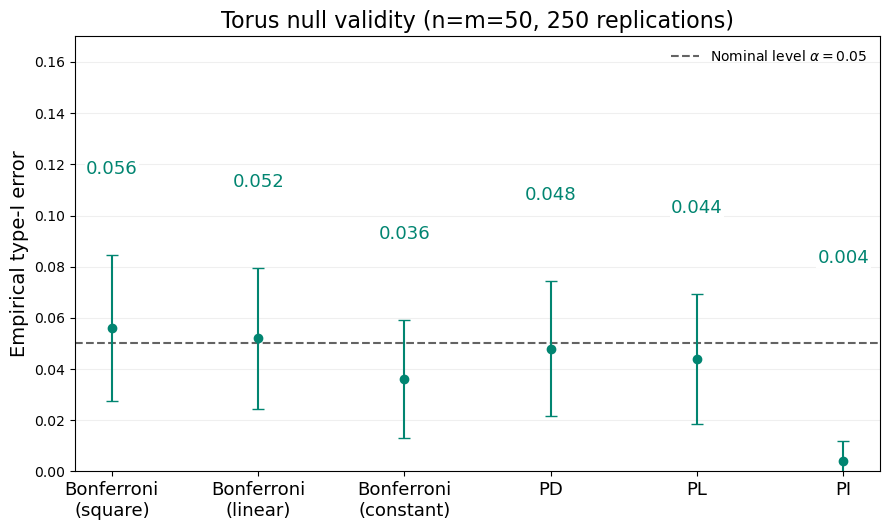

In [3]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr

RESULT_DIR = Path("results/simulation_results/Torus_results")
ALPHA = 0.05
N_REP = 250

methods = [
    "Bonferroni (square)", "Bonferroni (linear)",
    "Bonferroni (constant)", "PD", "PL", "PI"
]
files = [
    "bonferroni_null_square_rejections.pkl",
    "bonferroni_null_linear_rejections.pkl",
    "bonferroni_null_constant_rejections.pkl",
    "pd_null_pvalues.pkl",
    "pl_null_pvalues.pkl",
]

values = []
for name in files:
    with open(RESULT_DIR / name, "rb") as f:
        values.append(np.asarray(pickle.load(f)))


pi_rds = pyreadr.read_r(str(RESULT_DIR / "Torus_PI_validity_result.rds"))
pi_rate = float(np.asarray(next(iter(pi_rds.values()))).reshape(-1)[0])

rejected = [x.astype(bool) for x in values[:3]]
rejected += [x <= ALPHA for x in values[3:]]

counts = np.array([x.sum() for x in rejected] + [round(pi_rate * N_REP)], dtype=int)
rates = counts / N_REP
mcse = np.sqrt(rates * (1 - rates) / N_REP)

validity_summary = pd.DataFrame({
    "method": methods,
    "comparisons": N_REP,
    "rejections": counts,
    "empirical_type1_error": rates,
    "mcse": mcse,
})

colors = ["#018571"] * len(methods)
fig, ax = plt.subplots(figsize=(9, 5.4))
ax.axhline(ALPHA, color="#636363", ls="--",
           label=r"Nominal level $\alpha=0.05$")

label_y = np.maximum(rates + 1.96 * mcse, ALPHA) + 0.03
for i, (rate, se, color) in enumerate(zip(rates, mcse, colors)):
    ax.errorbar(i, rate, yerr=1.96 * se, fmt="o", color=color, capsize=4)
    ax.text(i, label_y[i], f"{rate:.3f}", ha="center", va="bottom",
            color=color, bbox=dict(facecolor="white", edgecolor="none", pad=1),
            fontsize=13)

ax.set_xticks(range(len(methods)))
ax.set_xticklabels([name.replace(" (", "\n(") for name in methods], fontsize=13)
ax.set_ylabel("Empirical type-I error", fontsize=14)
ax.set_title("Torus null validity (n=m=50, 250 replications)", fontsize=16)
ax.set_ylim(0, max(0.17, float(label_y.max()) + 0.05))
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(
    "results/figures/figure_file/torus_radius_validity_6methods.pdf",
    dpi=300,
)
plt.show()

In [90]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde, ks_2samp, kstest, norm, skew

sys.path.append(os.path.abspath("source"))
from TDA_Testing import *


# ============================================================
# 0. Settings
# ============================================================

N_SAMPLE = 500
M_SAMPLE = 500
REPETITIONS = 1000
REFERENCE_SIZE = 800
CHI_SQUARE_DRAWS = 30_000
FIXED_BANDWIDTH = (0.50, 0.50)
SHRINK_EXPONENT = 0.95
SEED = 20260928
MAX_BLOCK_ENTRIES = 1_000_000
OUTPUT_PREFIX = Path("asymptotic_null_histograms_n500")


# ============================================================
# 1. Weight function
# ============================================================

# This is w(b,d)=d-b. It can be changed to any weight in function_weight.
func_weight = function_weight("Poly", poly_order=1)


# ============================================================
# 2. Null model: P != Q, but p = q = 2F
# ============================================================

def sample_F(rng):
    """Draw (birth, death) from F."""
    birth = rng.uniform(1.5, 2.5)
    death = rng.uniform(4.5, 5.5)
    return birth, death


def single_circle_diagram(birth, death):
    """The exact Cech H1 diagram of the constructed circle X(b,d)."""
    return np.array([[birth, death]], dtype=float)


def sample_diagram_P(rng):
    """P: duplicate one F-distributed persistence point."""
    birth, death = sample_F(rng)
    diagram = single_circle_diagram(birth, death)
    return np.vstack((diagram, diagram.copy()))


def sample_diagram_Q(rng):
    """Q: take two independent F-distributed persistence points."""
    birth_1, death_1 = sample_F(rng)
    birth_2, death_2 = sample_F(rng)
    return np.vstack(
        (
            single_circle_diagram(birth_1, death_1),
            single_circle_diagram(birth_2, death_2),
        )
    )


def sample_groups(n, m, rng):
    X = [sample_diagram_P(rng) for _ in range(n)]
    Y = [sample_diagram_Q(rng) for _ in range(m)]
    return X, Y


# ============================================================
# 3. Simulation helpers
# ============================================================

def estimate_gamma_eigenvalues(reference_size, eta, bandwidth, rng):
    """Estimate the eigenvalues of Gamma_{eta,lambda}."""
    reference_diagrams = [
        sample_diagram_P(rng) if rng.random() < 1.0 - eta
        else sample_diagram_Q(rng)
        for _ in range(reference_size)
    ]

    geometry = prepare_geometry(reference_diagrams, func_weight=func_weight)
    gram = diagram_grams(
        geometry,
        [bandwidth],
        max_block_entries=MAX_BLOCK_ENTRIES,
    )[0]

    # H K H is the Gram matrix of empirically centered RKHS features.
    centered_gram = (
        gram
        - gram.mean(axis=0, keepdims=True)
        - gram.mean(axis=1, keepdims=True)
        + gram.mean()
    )
    centered_gram = 0.5 * (centered_gram + centered_gram.T)

    eigenvalues = np.linalg.eigvalsh(centered_gram / reference_size)
    largest = max(float(eigenvalues[-1]), 0.0)
    tolerance = max(1e-12, 1e-10 * largest)
    return eigenvalues[eigenvalues > tolerance][::-1]


def draw_weighted_centered_chi_square(weights, number_of_draws, rng):
    """Draw sum_l weights_l (Z_l^2-1) in memory-safe blocks."""
    draws = np.empty(number_of_draws, dtype=float)
    block_size = 1000

    for start in range(0, number_of_draws, block_size):
        stop = min(start + block_size, number_of_draws)
        normal_draws = rng.standard_normal((stop - start, len(weights)))
        draws[start:stop] = ((normal_draws**2 - 1.0) * weights).sum(axis=1)

    return draws


def robust_plot_range(first, second, padding=0.12):
    pooled = np.concatenate((first, second))
    lower, upper = np.quantile(pooled, [0.0025, 0.9975])
    width = max(upper - lower, 1e-8)
    return lower - padding * width, upper + padding * width


# ============================================================
# 4. Run the experiment
# ============================================================

rng = np.random.default_rng(SEED)
total_sample_size = N_SAMPLE + M_SAMPLE
eta = N_SAMPLE / total_sample_size
shrinking_scalar = total_sample_size ** (-SHRINK_EXPONENT)
shrinking_bandwidth = (shrinking_scalar, shrinking_scalar)

print(
    f"n=m={N_SAMPLE}, repetitions={REPETITIONS}, "
    f"fixed lambda={FIXED_BANDWIDTH}, shrinking lambda={shrinking_bandwidth}"
)
print(
    f"N^2 nu = {total_sample_size**2 * shrinking_scalar**2:.3f}"
)

fixed_scaled_u = np.empty(REPETITIONS, dtype=float)
shrinking_t = np.empty(REPETITIONS, dtype=float)
nonpositive_variance = 0

for repetition in range(REPETITIONS):
    X, Y = sample_groups(N_SAMPLE, M_SAMPLE, rng)
    geometry = prepare_geometry(X + Y, func_weight=func_weight)

    fixed_gram, shrinking_gram = diagram_grams(
        geometry,
        [FIXED_BANDWIDTH, shrinking_bandwidth],
        max_block_entries=MAX_BLOCK_ENTRIES,
    )

    _, fixed_u, _ = T_statistic(fixed_gram, N_SAMPLE, M_SAMPLE)
    statistic, _, variance_estimate = T_statistic(
        shrinking_gram, N_SAMPLE, M_SAMPLE
    )

    fixed_scaled_u[repetition] = total_sample_size * fixed_u

    if np.isfinite(statistic) and variance_estimate > 0.0:
        shrinking_t[repetition] = statistic
    else:
        # The theoretical convention is T=0 on the zero-variance event.
        shrinking_t[repetition] = 0.0
        nonpositive_variance += 1

    if (repetition + 1) % 100 == 0:
        print(f"Simulation progress: {repetition + 1}/{REPETITIONS}")


# Estimate the fixed-bandwidth weighted chi-square limit.
gamma_hat = estimate_gamma_eigenvalues(
    REFERENCE_SIZE,
    eta,
    FIXED_BANDWIDTH,
    rng,
)

# The standard limit is for N_eff U. Since the left panel uses N U,
# multiply the estimated eigenvalues by N/N_eff=1/[eta(1-eta)].
scaled_weights = gamma_hat / (eta * (1.0 - eta))
weighted_chi_square = draw_weighted_centered_chi_square(
    scaled_weights,
    CHI_SQUARE_DRAWS,
    rng,
)


# ============================================================
# 5. Diagnostics
# ============================================================

fixed_ks = ks_2samp(fixed_scaled_u, weighted_chi_square).statistic
normal_ks = kstest(shrinking_t, "norm").statistic

print("\nFixed-bandwidth comparison")
print(
    f"  empirical: mean={fixed_scaled_u.mean():.3f}, "
    f"sd={fixed_scaled_u.std(ddof=1):.3f}, "
    f"skewness={skew(fixed_scaled_u, bias=False):.3f}"
)
print(
    f"  weighted chi-square: mean={weighted_chi_square.mean():.3f}, "
    f"sd={weighted_chi_square.std(ddof=1):.3f}, "
    f"skewness={skew(weighted_chi_square, bias=False):.3f}"
)
print(f"  two-sample KS statistic={fixed_ks:.3f}")

print("\nShrinking-bandwidth studentized statistic")
print(
    f"  mean={shrinking_t.mean():.3f}, "
    f"sd={shrinking_t.std(ddof=1):.3f}, "
    f"skewness={skew(shrinking_t, bias=False):.3f}"
)
print(f"  KS statistic against N(0,1)={normal_ks:.3f}")
print(f"  nonpositive variance count={nonpositive_variance}")





n=m=500, repetitions=1000, fixed lambda=(0.5, 0.5), shrinking lambda=(0.0014125375446227548, 0.0014125375446227548)
N^2 nu = 1.995
Simulation progress: 100/1000
Simulation progress: 200/1000
Simulation progress: 300/1000
Simulation progress: 400/1000
Simulation progress: 500/1000
Simulation progress: 600/1000
Simulation progress: 700/1000
Simulation progress: 800/1000
Simulation progress: 900/1000
Simulation progress: 1000/1000

Fixed-bandwidth comparison
  empirical: mean=-0.327, sd=22.996, skewness=2.031
  weighted chi-square: mean=-0.165, sd=22.913, skewness=1.800
  two-sample KS statistic=0.033

Shrinking-bandwidth studentized statistic
  mean=-0.078, sd=0.991, skewness=-0.078
  KS statistic against N(0,1)=0.038
  nonpositive variance count=0


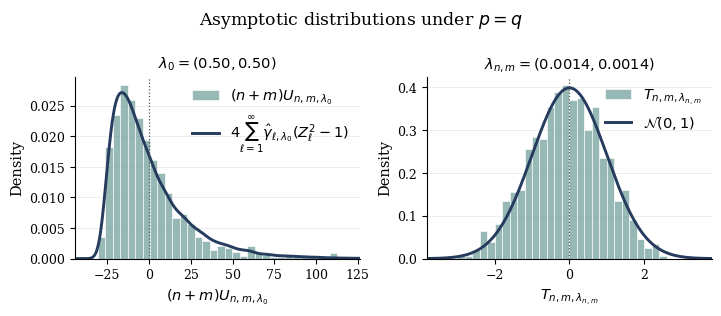

In [191]:
# ============================================================
# 6. Plot and save
# ============================================================

plt.rcParams.update(
    {
        "font.family": "DejaVu Serif",
        "font.size": 9.5,
        "axes.titlesize": 10.5,
        "axes.labelsize": 10.5,
        "legend.fontsize": 10.5,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

empirical_color = "#6F9E9A"  # muted teal
theory_color    = "#263B5E"  # deep navy
normal_color    = theory_color
zero_line_color = "#6E6E6E"
grid_color      = "#D9D9D9"

# A4 manuscript의 full-text width에 맞춘 크기
figure, axes = plt.subplots(
    1,
    2,
    figsize=(7.1, 3.05),
    constrained_layout=True,
)

# ------------------------------------------------------------
# Left: fixed bandwidth and weighted centered chi-square limit
# ------------------------------------------------------------

left_min, left_max = robust_plot_range(
    fixed_scaled_u,
    weighted_chi_square,
)
left_grid = np.linspace(left_min, left_max, 600)
limit_density = gaussian_kde(weighted_chi_square)(left_grid)

axes[0].hist(
    fixed_scaled_u,
    bins=38,
    range=(left_min, left_max),
    density=True,
    color=empirical_color,
    alpha=0.72,
    edgecolor="white",
    linewidth=0.6,
    label=r"$(n+m)U_{n,m,\lambda_0}$",
)

axes[0].plot(
    left_grid,
    limit_density,
    color=theory_color,
    linewidth=2.1,
    label=r"$4\sum_{\ell=1}^{\infty}\hat{\gamma}_{\ell,\lambda_0}(Z_\ell^2-1)$",
)

axes[0].axvline(
    0.0,
    color="#555555",
    linewidth=0.9,
    linestyle=":",
)

axes[0].set_xlim(left_min, left_max)
axes[0].set_xlabel(r"$(n+m)U_{n,m,\lambda_0}$")
axes[0].set_ylabel("Density")

axes[0].set_title(
    r""
    + "\n"
    + rf"$\lambda_0="
      rf"({FIXED_BANDWIDTH[0]:.2f},"
      rf"{FIXED_BANDWIDTH[1]:.2f})$"
)

axes[0].legend(
    frameon=False,
    loc="upper right",
    handlelength=1.8,
    borderaxespad=0.3,
)

# ------------------------------------------------------------
# Right: shrinking bandwidth and standard normal limit
# ------------------------------------------------------------

right_min, right_max = robust_plot_range(
    shrinking_t,
    np.array([-4.0, 4.0]),
)
right_min = min(right_min, -3.8)
right_max = max(right_max, 3.8)
right_grid = np.linspace(right_min, right_max, 600)

axes[1].hist(
    shrinking_t,
    bins=38,
    range=(right_min, right_max),
    density=True,
    color=empirical_color,
    alpha=0.72,
    edgecolor="white",
    linewidth=0.6,
    label=r"$T_{n,m,\lambda_{n,m}}$",
)

axes[1].plot(
    right_grid,
    norm.pdf(right_grid),
    color=normal_color,
    linewidth=2.1,
    label=r"$\mathcal{N}(0,1)$",
)

axes[1].axvline(
    0.0,
    color="#555555",
    linewidth=0.9,
    linestyle=":",
)

axes[1].set_xlim(right_min, right_max)
axes[1].set_xlabel(r"$T_{n,m,\lambda_{n,m}}$")
axes[1].set_ylabel("Density")

axes[1].set_title(
    "\n"
    + rf"$\lambda_{{n,m}}="
      rf"({shrinking_scalar:.4f},"
      rf"{shrinking_scalar:.4f})$"
)

axes[1].legend(
    frameon=False,
    loc="upper right",
    handlelength=1.8,
    borderaxespad=0.3,
)

for axis in axes:
    axis.grid(
        axis="y",
        color="#D8D8D8",
        linewidth=0.5,
        alpha=0.6,
    )
    axis.set_axisbelow(True)

figure.suptitle(
    rf"Asymptotic distributions under $p=q$ ",
    fontsize=12.5,
)
pdf_path = Path("results/figures/figure_file") / OUTPUT_PREFIX.with_suffix(".pdf")

figure.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.04,
)

plt.show()

Simulation progress: 100/1000
Simulation progress: 200/1000
Simulation progress: 300/1000
Simulation progress: 400/1000
Simulation progress: 500/1000
Simulation progress: 600/1000
Simulation progress: 700/1000
Simulation progress: 800/1000
Simulation progress: 900/1000
Simulation progress: 1000/1000
N=60, s_nm=2.78316, L_nm=2, K_nm=8, |Lambda|=15
lambda_b, lambda_d are fixed by (n,m), without data calibration.
(k1,k2) | (lambda_b,lambda_d) | KS vs N(0,1) | Pr(T > 1.645)
(2, 2) | (0.25, 0.25) | 0.0741 | 0.065
(2, 3) | (0.25, 0.125) | 0.0670 | 0.060
(2, 4) | (0.25, 0.0625) | 0.0466 | 0.058
(2, 5) | (0.25, 0.03125) | 0.0453 | 0.064
(2, 6) | (0.25, 0.015625) | 0.0346 | 0.051
(3, 2) | (0.125, 0.25) | 0.0577 | 0.071
(3, 3) | (0.125, 0.125) | 0.0466 | 0.049
(3, 4) | (0.125, 0.0625) | 0.0405 | 0.051
(3, 5) | (0.125, 0.03125) | 0.0301 | 0.060
(4, 2) | (0.0625, 0.25) | 0.0398 | 0.063
(4, 3) | (0.0625, 0.125) | 0.0344 | 0.051
(4, 4) | (0.0625, 0.0625) | 0.0333 | 0.049
(5, 2) | (0.03125, 0.25) | 0

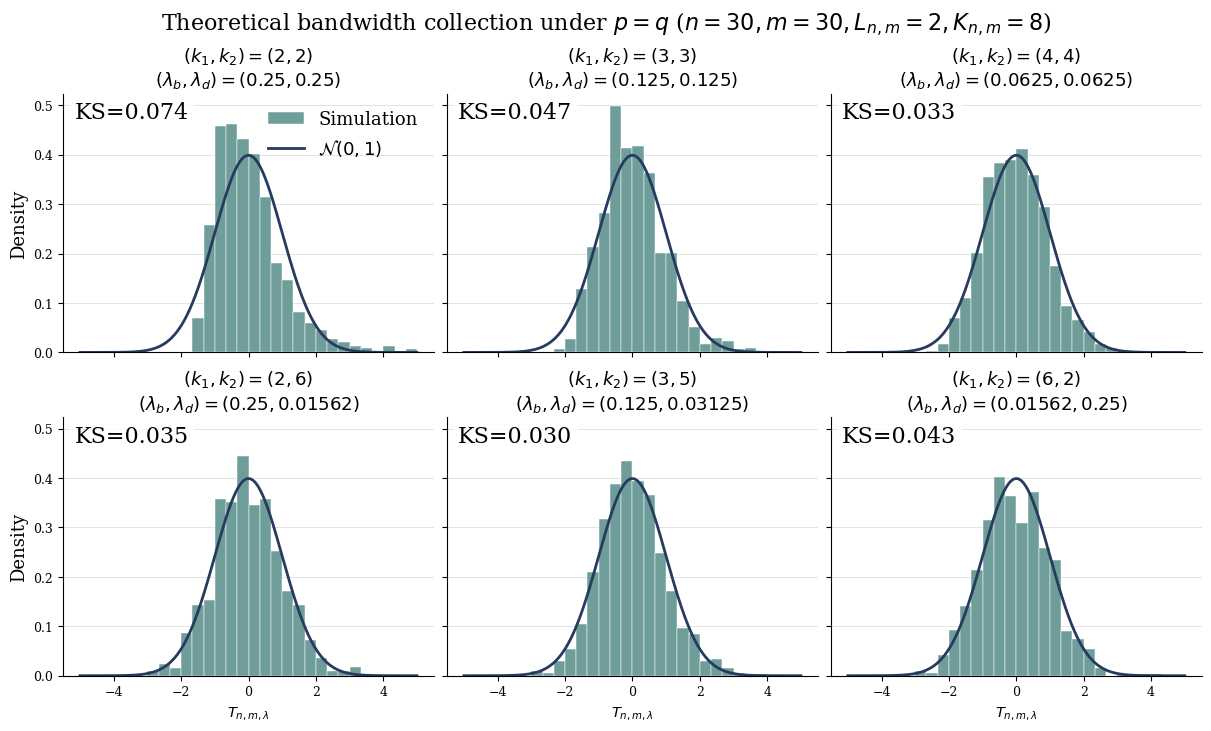

In [157]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kstest, norm


# ============================================================
# 1. Settings
# ============================================================

N_SAMPLE = 30
M_SAMPLE = 30
REPETITIONS = 1000
A_EXPONENT = 6.0
ALPHA = 0.05
SEED = 20260928

OUTPUT_DIR = Path("results/figures/figure_file")
OUTPUT_STEM = (
    f"largest_bandwidth_fail_n{N_SAMPLE}_m{M_SAMPLE}"
)


# ============================================================
# 2. Diagram distributions
# ============================================================

def sample_F(rng):
    """Draw one birth-death point from F."""
    return np.array(
        [rng.uniform(1.5, 2.5), rng.uniform(4.5, 5.5)],
        dtype=float,
    )


def sample_groups(n, m, rng):
    """P duplicates one F point; Q draws two independent F points."""
    X = [np.repeat(sample_F(rng)[None, :], 2, axis=0) for _ in range(n)]
    Y = [np.stack((sample_F(rng), sample_F(rng))) for _ in range(m)]
    return X, Y


# ============================================================
# 3. The paper's bandwidth collection (no shift parameter)
# ============================================================

def theoretical_bandwidth_indices(n, m, a):
    """Return s_nm, L_nm, K_nm and all (k1,k2) in the paper's Lambda."""
    total = n + m
    if total < 2 or a <= 5.0:
        raise ValueError("Require n+m >= 2 and a > 5.")

    s_nm = min(np.log2(total)**a, total**0.25)
    L_nm = int(np.ceil(np.log2(s_nm)))
    K_nm = int(np.floor(2.0 * np.log2(total / s_nm)))
    indices = [
        (k1, k2)
        for k1 in range(L_nm, K_nm - L_nm + 1)
        for k2 in range(L_nm, K_nm - k1 + 1)
    ]
    if not indices:
        raise ValueError("The theoretical bandwidth collection is empty.")
    return s_nm, L_nm, K_nm, indices


def representative_indices(L_nm, K_nm, collection):
    """Three diagonal pairs, then three pairs on k1+k2=K_nm."""
    chosen = [
        (L_nm, L_nm),
        (L_nm + 1, L_nm + 1),
        (K_nm // 2, K_nm // 2),
        (L_nm, K_nm - L_nm),
        (L_nm + 1, K_nm - L_nm - 1),
        (K_nm - L_nm, L_nm),
    ]
    if len(set(chosen)) != 6 or not set(chosen).issubset(collection):
        raise ValueError(
            "This six-panel layout requires a larger nonempty collection; "
            "try a larger sample size."
        )
    return chosen


# ============================================================
# 4. Studentized statistic
# ============================================================

def a_hat(gram):
    """Fourth-order unbiased estimator of tr(Sigma**2)."""
    r = len(gram)
    off = np.array(gram, copy=True)
    np.fill_diagonal(off, 0.0)

    row_sum = off.sum(axis=1)
    numerator = (
        row_sum.sum() ** 2
        - 2.0 * (r - 1) * np.sum(row_sum**2)
        + (r - 1) * (r - 2) * np.sum(off**2)
    )
    return float(numerator / (r * (r - 1) * (r - 2) * (r - 3)))


def a_pq_hat(gram_xy):
    """Unbiased estimator of tr(Sigma_P Sigma_Q)."""
    n, m = gram_xy.shape
    row_sum = gram_xy.sum(axis=1)
    col_sum = gram_xy.sum(axis=0)

    numerator = (
        gram_xy.sum() ** 2
        - n * np.sum(row_sum**2)
        - m * np.sum(col_sum**2)
        + n * m * np.sum(gram_xy**2)
    )
    return float(numerator / (n * (n - 1) * m * (m - 1)))


def studentized_u(gram, n, m):
    """Compute T_{n,m,lambda}; set it to zero if variance is nonpositive."""
    xx = gram[:n, :n]
    yy = gram[n:, n:]
    xy = gram[:n, n:]

    u_statistic = (
        (xx.sum() - np.trace(xx)) / (n * (n - 1))
        + (yy.sum() - np.trace(yy)) / (m * (m - 1))
        - 2.0 * xy.sum() / (n * m)
    )

    variance_estimate = (
        2.0 * a_hat(xx) / (n * (n - 1))
        + 2.0 * a_hat(yy) / (m * (m - 1))
        + 4.0 * a_pq_hat(xy) / (n * m)
    )

    if not np.isfinite(variance_estimate) or variance_estimate <= 0:
        return 0.0

    return float(u_statistic / np.sqrt(variance_estimate))


def prepare_pair_geometry(X, Y):
    """Cache point differences shared by every bandwidth in Lambda."""
    diagrams = X + Y
    if any(diagram.shape != (2, 2) for diagram in diagrams):
        raise ValueError("Each diagram must contain exactly two points.")
    flat = np.stack(diagrams).reshape(-1, 2)
    weights = flat[:, 1] - flat[:, 0]
    birth_sq = (flat[:, None, 0] - flat[None, :, 0])**2
    death_sq = (flat[:, None, 1] - flat[None, :, 1])**2
    return birth_sq, death_sq, np.outer(weights, weights), len(diagrams)


def gaussian_diagram_gram(geometry, bandwidth):
    """Anisotropic Gaussian Gram matrix with linear persistence weight."""
    birth_sq, death_sq, weight_products, count = geometry
    h_b, h_d = bandwidth
    point_kernel = (
        weight_products
        * np.exp(-0.5 * (birth_sq / h_b**2 + death_sq / h_d**2))
        / (2.0 * np.pi * h_b * h_d)
    )
    return point_kernel.reshape(count, 2, count, 2).sum(axis=(1, 3))


# ============================================================
# 5. Simulate every bandwidth in Lambda, with the same data in each repetition
# ============================================================

def run_experiment():
    main_rng = np.random.default_rng(np.random.SeedSequence([SEED, 1]))
    s_nm, L_nm, K_nm, indices = theoretical_bandwidth_indices(
        N_SAMPLE, M_SAMPLE, A_EXPONENT
    )
    panels = representative_indices(L_nm, K_nm, indices)
    bandwidths = [tuple(2.0**(-k) for k in pair) for pair in indices]
    statistics = np.empty((len(indices), REPETITIONS), dtype=float)

    for r in range(REPETITIONS):
        X, Y = sample_groups(N_SAMPLE, M_SAMPLE, main_rng)
        geometry = prepare_pair_geometry(X, Y)
        for j, bandwidth in enumerate(bandwidths):
            gram = gaussian_diagram_gram(geometry, bandwidth)
            statistics[j, r] = studentized_u(
                gram, N_SAMPLE, M_SAMPLE
            )

        if (r + 1) % 100 == 0:
            print(f"Simulation progress: {r + 1}/{REPETITIONS}")

    print(
        f"N={N_SAMPLE + M_SAMPLE}, s_nm={s_nm:.6g}, "
        f"L_nm={L_nm}, K_nm={K_nm}, |Lambda|={len(indices)}"
    )
    print("lambda_b, lambda_d are fixed by (n,m), without data calibration.")
    print(
        "(k1,k2) | (lambda_b,lambda_d) | KS vs N(0,1) | "
        f"Pr(T > {norm.isf(ALPHA):.3f})"
    )
    for j, pair in enumerate(indices):
        values = statistics[j]
        ks = kstest(values, "norm").statistic
        print(
            f"{pair} | {bandwidths[j]} | {ks:.4f} | "
            f"{np.mean(values > norm.isf(ALPHA)):.3f}"
        )

    return statistics, bandwidths, indices, panels, L_nm, K_nm


# ============================================================
# 6. Plot: three diagonal bandwidths and three boundary bandwidths
# ============================================================

def save_figure(statistics, bandwidths, indices, panels, L_nm, K_nm):
    plt.rcParams.update({
        "font.family": "DejaVu Serif",
        "font.size": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })
    figure, axes = plt.subplots(
        2, 3,
        figsize=(12.0, 7.2),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    panel_ids = [indices.index(pair) for pair in panels]
    horizontal_limit = max(
        5.0, float(np.quantile(np.abs(statistics[panel_ids]), 0.999))
    )
    edges = np.linspace(-horizontal_limit, horizontal_limit, 31)
    bin_width = edges[1] - edges[0]
    grid = np.linspace(-horizontal_limit, horizontal_limit, 800)

    for panel_number, ax in enumerate(axes.flat):
        index = panel_ids[panel_number]
        k1, k2 = panels[panel_number]
        h_b, h_d = bandwidths[index]
        values = statistics[index]

        # Keep normalization based on all repetitions even if some
        # observations fall outside the plotted horizontal range.
        weights = np.full(
            REPETITIONS, 1.0 / (REPETITIONS * bin_width)
        )

        ax.hist(
            values,
            bins=edges,
            weights=weights,
            color="#6F9E9A",
            edgecolor="white",
            linewidth=0.35,
            label="Simulation",
        )
        ax.plot(
            grid,
            norm.pdf(grid),
            color="#263B5E",
            linewidth=2.0,
            label=r"$\mathcal{N}(0,1)$",
        )
        # ax.axvline(
        #     norm.isf(ALPHA), color="#B75C45", linewidth=1.0,
        #     linestyle=":", label="Normal 5% cutoff",
        # )

        ax.set_title(
            rf"$(k_1,k_2)=({k1},{k2})$"
            + "\n"
            + rf"$(\lambda_b,\lambda_d)=({h_b:.4g},{h_d:.4g})$",
            fontsize=13,
        )

        if panel_number >= 3:
            ax.set_xlabel(r"$T_{n,m,\lambda}$")

        ax.grid(axis="y", color="#D8D8D8", linewidth=0.5)
        ax.set_axisbelow(True)
        ax.text(
            0.03,
            0.97,
            f"KS={kstest(values, 'norm').statistic:.3f}\n",
            # f"Right tail={np.mean(values > norm.isf(ALPHA)):.3f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=16,
            bbox={
                "facecolor": "white",
                "alpha": 0.82,
                "edgecolor": "none",
            },
        )

    axes[0, 0].set_ylabel("Density", fontsize=13)
    axes[1, 0].set_ylabel("Density", fontsize=13)
    axes[0, 0].legend(
        frameon=False, fontsize=13, loc="upper right"
    )

    figure.suptitle(
        rf"Theoretical bandwidth collection under $p=q$ "
        + rf"($n={N_SAMPLE},m={M_SAMPLE},L_{{n,m}}={L_nm},"
        + rf"K_{{n,m}}={K_nm}$)",
        fontsize=16,
    )

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    png_path = OUTPUT_DIR / f"{OUTPUT_STEM}.png"
    pdf_path = OUTPUT_DIR / f"{OUTPUT_STEM}.pdf"

    # figure.savefig(png_path, dpi=300, bbox_inches="tight")
    figure.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved {png_path} and {pdf_path}")

    plt.show()
    plt.close(figure)


save_figure(*run_experiment())


Simulation progress: 200/1000
Simulation progress: 400/1000
Simulation progress: 600/1000
Simulation progress: 800/1000
Simulation progress: 1000/1000
n=m=30, repetitions=1000, s_nm=2.7832, L_nm=2, K_nm=8, |Lambda_c|=15
The diagnostic shift c rescales every bandwidth by 2^(-c).
c | boundary       | (k_b,k_d) | (h_b,h_d)             | KS    | right tail
0 | min birth      | ( 6, 2)   | (0.015625,0.250000) | 0.0430 | 0.054
0 | balanced       | ( 4, 4)   | (0.062500,0.062500) | 0.0333 | 0.049
0 | min death      | ( 2, 6)   | (0.250000,0.015625) | 0.0346 | 0.051
1 | min birth      | ( 7, 3)   | (0.007812,0.125000) | 0.0427 | 0.038
1 | balanced       | ( 5, 5)   | (0.031250,0.031250) | 0.0336 | 0.039
1 | min death      | ( 3, 7)   | (0.125000,0.007812) | 0.0287 | 0.039
2 | min birth      | ( 8, 4)   | (0.003906,0.062500) | 0.0523 | 0.026
2 | balanced       | ( 6, 6)   | (0.015625,0.015625) | 0.0419 | 0.027
2 | min death      | ( 4, 8)   | (0.062500,0.003906) | 0.0513 | 0.040
3 | min birth  

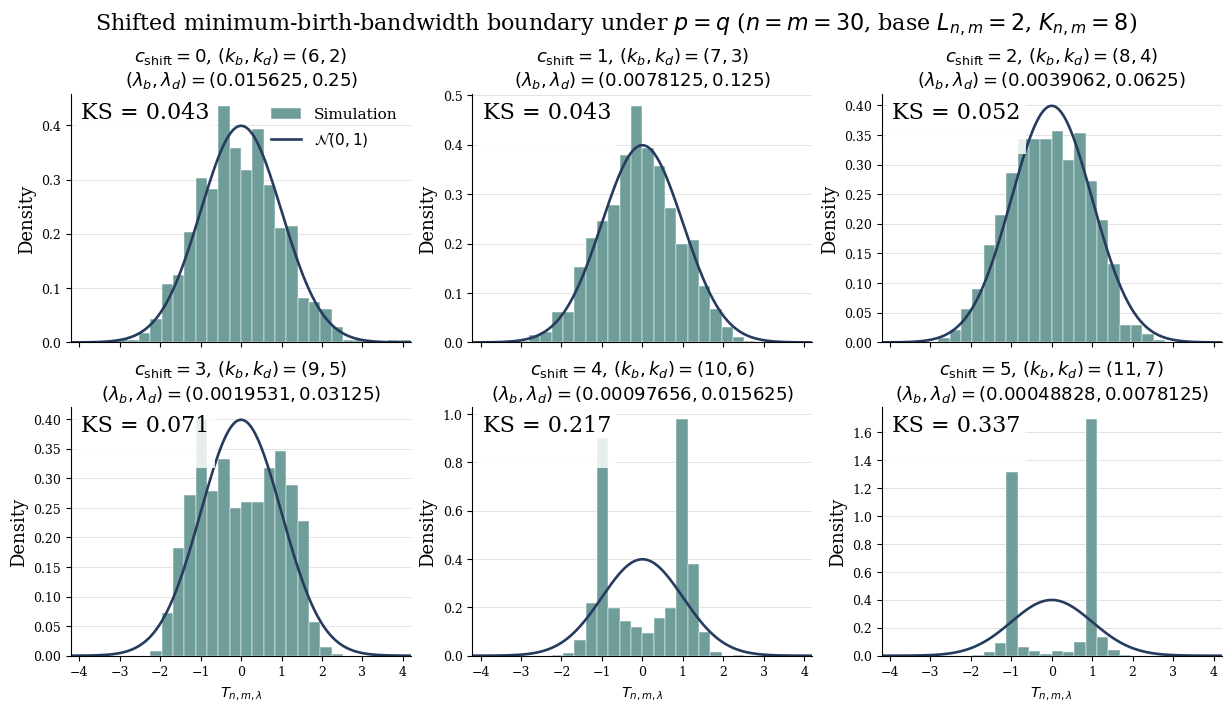

In [158]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kstest, norm


# One notebook cell: n=m=30, same null model and seed as before.
N_SAMPLE = 30
M_SAMPLE = 30
REPETITIONS = 1000
A_EXPONENT = 6.0                # a > 5 in the theoretical collection
SHIFT_VALUES = tuple(range(6))  # c_shift = 0, 1, ..., 5
ALPHA = 0.05
SEED = 20260928
OUTPUT_DIR = Path("results/figures/figure_file")
OUTPUT_STEM = "shifted_fail"


def sample_F(rng):
    return np.array(
        [rng.uniform(1.5, 2.5), rng.uniform(4.5, 5.5)],
        dtype=float,
    )


def sample_groups(n, m, rng):
    # P duplicates a single point, Q draws two independent points; p=q=2F.
    X = [np.repeat(sample_F(rng)[None, :], 2, axis=0) for _ in range(n)]
    Y = [np.stack((sample_F(rng), sample_F(rng))) for _ in range(m)]
    return X, Y


def theoretical_bandwidth_indices(n, m, a):
    total = n + m
    if total < 2 or a <= 5:
        raise ValueError("Require n+m >= 2 and a > 5.")
    s_nm = min(np.log2(total)**a, total**0.25)
    L_nm = int(np.ceil(np.log2(s_nm)))
    K_nm = int(np.floor(2 * np.log2(total / s_nm)))
    indices = [
        (k_b, k_d)
        for k_b in range(L_nm, K_nm - L_nm + 1)
        for k_d in range(L_nm, K_nm - k_b + 1)
    ]
    if not indices:
        raise ValueError("Empty theoretical bandwidth collection.")
    return s_nm, L_nm, K_nm, indices


def shifted_collection(base_indices, L_nm, K_nm, c_shift):
    # Diagnostic shift only: Lambda_c = 2^(-c_shift) Lambda_0.
    L_shifted = L_nm + c_shift
    K_shifted = K_nm + 2 * c_shift
    indices = [(k_b + c_shift, k_d + c_shift) for k_b, k_d in base_indices]
    assert all(
        k_b >= L_shifted and k_d >= L_shifted
        and k_b + k_d <= K_shifted
        for k_b, k_d in indices
    )
    return L_shifted, K_shifted, indices


def a_hat(gram):
    """Fourth-order unbiased estimate of tr(Sigma**2), as before."""
    r = len(gram)
    off = np.array(gram, copy=True)
    np.fill_diagonal(off, 0.0)
    row_sum = off.sum(axis=1)
    numerator = (
        row_sum.sum()**2
        - 2.0 * (r - 1) * np.sum(row_sum**2)
        + (r - 1) * (r - 2) * np.sum(off**2)
    )
    return float(numerator / (r * (r - 1) * (r - 2) * (r - 3)))


def a_pq_hat(gram_xy):
    """Unbiased estimate of tr(Sigma_P Sigma_Q), as before."""
    n, m = gram_xy.shape
    row_sum = gram_xy.sum(axis=1)
    col_sum = gram_xy.sum(axis=0)
    numerator = (
        gram_xy.sum()**2
        - n * np.sum(row_sum**2)
        - m * np.sum(col_sum**2)
        + n * m * np.sum(gram_xy**2)
    )
    return float(numerator / (n * (n - 1) * m * (m - 1)))


def studentized_u(gram, n, m):
    """Studentized U; sum off-diagonals directly for small bandwidths."""
    xx, yy, xy = gram[:n, :n], gram[n:, n:], gram[:n, n:]
    # sum(gram) - trace(gram) loses precision when the kernel diagonal is huge.
    u_statistic = (
        2.0 * np.triu(xx, k=1).sum() / (n * (n - 1))
        + 2.0 * np.triu(yy, k=1).sum() / (m * (m - 1))
        - 2.0 * xy.mean()
    )
    variance_estimate = (
        2.0 * a_hat(xx) / (n * (n - 1))
        + 2.0 * a_hat(yy) / (m * (m - 1))
        + 4.0 * a_pq_hat(xy) / (n * m)
    )
    if not np.isfinite(variance_estimate) or variance_estimate <= 0.0:
        return 0.0  # Same theoretical convention as the original experiment.
    return float(u_statistic / np.sqrt(variance_estimate))


def prepare_pair_geometry(X, Y):
    diagrams = X + Y
    flat = np.stack(diagrams).reshape(-1, 2)
    weights = flat[:, 1] - flat[:, 0]  # w(b,d)=d-b
    birth_sq = (flat[:, None, 0] - flat[None, :, 0])**2
    death_sq = (flat[:, None, 1] - flat[None, :, 1])**2
    return birth_sq, death_sq, np.outer(weights, weights), len(diagrams)


def gaussian_diagram_gram(geometry, bandwidth):
    birth_sq, death_sq, weight_products, count = geometry
    h_b, h_d = bandwidth
    point_kernel = (
        weight_products
        * np.exp(-0.5 * (birth_sq / h_b**2 + death_sq / h_d**2))
        / (2.0 * np.pi * h_b * h_d)
    )
    return point_kernel.reshape(count, 2, count, 2).sum(axis=(1, 3))


def run_experiment():
    s_nm, L_nm, K_nm, base_indices = theoretical_bandwidth_indices(
        N_SAMPLE, M_SAMPLE, A_EXPONENT
    )
    candidates = []
    for c_shift in SHIFT_VALUES:
        L_c, K_c, indices = shifted_collection(
            base_indices, L_nm, K_nm, c_shift
        )
        # All three pairs lie on k_b+k_d=K_c (smallest bandwidth product).
        for label, pair in (
            ("min birth", (K_c - L_c, L_c)),
            ("balanced", (K_c // 2, K_c // 2)),
            ("min death", (L_c, K_c - L_c)),
        ):
            assert pair in indices
            candidates.append((c_shift, label, pair))

    statistics = np.empty((len(candidates), REPETITIONS), dtype=float)
    rng = np.random.default_rng(np.random.SeedSequence([SEED, 1]))
    for repetition in range(REPETITIONS):
        X, Y = sample_groups(N_SAMPLE, M_SAMPLE, rng)
        geometry = prepare_pair_geometry(X, Y)
        for j, (_, _, (k_b, k_d)) in enumerate(candidates):
            bandwidth = (2.0**(-k_b), 2.0**(-k_d))
            gram = gaussian_diagram_gram(geometry, bandwidth)
            statistics[j, repetition] = studentized_u(
                gram, N_SAMPLE, M_SAMPLE
            )
        if (repetition + 1) % 200 == 0:
            print(f"Simulation progress: {repetition + 1}/{REPETITIONS}")

    cutoff = norm.isf(ALPHA)
    print(
        f"n=m={N_SAMPLE}, repetitions={REPETITIONS}, "
        f"s_nm={s_nm:.5g}, L_nm={L_nm}, K_nm={K_nm}, "
        f"|Lambda_c|={len(base_indices)}"
    )
    print("The diagnostic shift c rescales every bandwidth by 2^(-c).")
    print("c | boundary       | (k_b,k_d) | (h_b,h_d)             | KS    | right tail")
    for j, (c, label, (k_b, k_d)) in enumerate(candidates):
        values = statistics[j]
        print(
            f"{c} | {label:<14} | ({k_b:2d},{k_d:2d})   | "
            f"({2.0**(-k_b):.6f},{2.0**(-k_d):.6f}) | "
            f"{kstest(values, 'norm').statistic:.4f} | "
            f"{np.mean(values > cutoff):.3f}"
        )
    return statistics, candidates, L_nm, K_nm


def save_figure(statistics, candidates, L_nm, K_nm):
    plt.rcParams.update({
        "font.family": "DejaVu Serif",
        "font.size": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })
    figure, axes = plt.subplots(
        2, 3, figsize=(12.2, 7.0),
        sharex=True, constrained_layout=True,
    )
    # Plot the endpoint whose birth bandwidth is the smallest in Lambda_c.
    plot_indices = [
        j for j, (_, label, _) in enumerate(candidates) if label == "min birth"
    ]
    x_limit = max(4.2, float(np.quantile(np.abs(statistics[plot_indices]), 0.999)))
    bins = np.linspace(-x_limit, x_limit, 31)
    grid = np.linspace(-x_limit, x_limit, 800)
    cutoff = norm.isf(ALPHA)

    for ax, j in zip(axes.flat, plot_indices):
        c, _, (k_b, k_d) = candidates[j]
        values = statistics[j]
        h_b, h_d = 2.0**(-k_b), 2.0**(-k_d)
        # Count all repetitions, even if a value lies outside the plot limits.
        ax.hist(
            values, bins=bins,
            weights=np.full(len(values), 1.0 / (len(values) * (bins[1]-bins[0]))),
            color="#6F9E9A", edgecolor="white", linewidth=0.35,
            label="Simulation",
        )
        ax.plot(
            grid, norm.pdf(grid), color="#263B5E", lw=1.9,
            label=r"$\mathcal{N}(0,1)$",
        )
        # ax.axvline(
        #     cutoff, color="#B75C45", lw=1.0, ls=":",
        #     label="5% cutoff",
        # )
        ax.set_title(
            rf"$c_{{\mathrm{{shift}}}}={c}$, $(k_b,k_d)=({k_b},{k_d})$"
            + "\n"
            + rf"$(\lambda_b,\lambda_d)=({h_b:.5g},{h_d:.5g})$",
            fontsize=13,
        )
        ax.text(
            0.03, 0.97,
            f"KS = {kstest(values, 'norm').statistic:.3f}\n",
            # f"Right tail = {np.mean(values > cutoff):.3f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=16,
            bbox={"facecolor": "white", "alpha": 0.84, "edgecolor": "none"},
        )
        ax.set_xlim(-x_limit, x_limit)
        ax.set_ylabel("Density",fontsize=13)
        ax.grid(axis="y", color="#D8D8D8", lw=0.5)
        ax.set_axisbelow(True)

    for ax in axes[1]:
        ax.set_xlabel(r"$T_{n,m,\lambda}$")
    axes[0, 0].legend(frameon=False, fontsize=11, loc="upper right")
    figure.suptitle(
        rf"Shifted minimum-birth-bandwidth boundary under $p=q$ "
        rf"($n=m={N_SAMPLE}$, base $L_{{n,m}}={L_nm}$, $K_{{n,m}}={K_nm}$)",
        fontsize=16,
    )
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    png_path = OUTPUT_DIR / f"{OUTPUT_STEM}.png"
    pdf_path = OUTPUT_DIR / f"{OUTPUT_STEM}.pdf"
    # figure.savefig(png_path, dpi=220, bbox_inches="tight")
    figure.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved figure: {png_path} and {pdf_path}")
    plt.show()
    plt.close(figure)


save_figure(*run_experiment())


Completed 200/1000 repetitions
Completed 400/1000 repetitions
Completed 600/1000 repetitions
Completed 800/1000 repetitions
Completed 1000/1000 repetitions
Median reference scales: r_b=0.294188, r_d=0.294664
One-sided Bonferroni cutoff: 2.5392
offsets (j,k) | median h_b | median h_d | KS vs N(0,1) | Pr(T > cutoff)
(-1,-1) | 0.0189898 | 0.0190205 | 0.041 | 0.001
(-1,+0) | 0.0189898 | 0.038041 | 0.043 | 0.002
(-1,+1) | 0.0189898 | 0.076082 | 0.035 | 0.005
(+0,-1) | 0.0379796 | 0.0190205 | 0.023 | 0.001
(+0,+0) | 0.0379796 | 0.038041 | 0.034 | 0.001
(+0,+1) | 0.0379796 | 0.076082 | 0.048 | 0.003
(+1,-1) | 0.0759591 | 0.0190205 | 0.025 | 0.005
(+1,+0) | 0.0759591 | 0.038041 | 0.028 | 0.005
(+1,+1) | 0.0759591 | 0.076082 | 0.040 | 0.009
Aggregated rejection frequency at alpha=0.05: 0.019


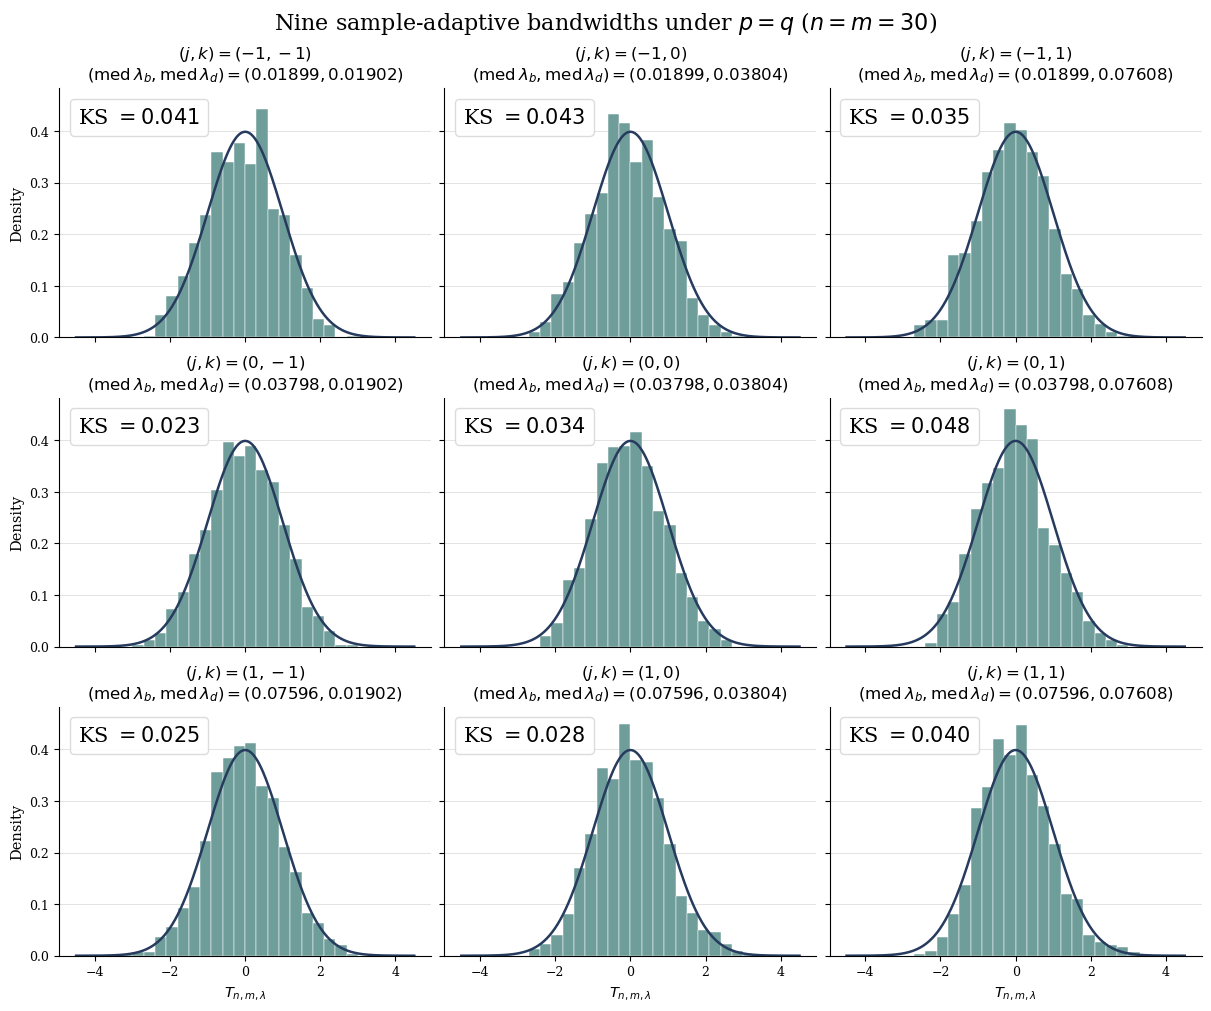

Saved: results/figures/figure_file/our_choice_adaptive_n30_m30_nine.pdf


In [155]:
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kstest, norm


# One notebook cell: recalculate reference and bandwidths in every repetition.
N_SAMPLE = M_SAMPLE = 30
REPETITIONS = 1000
ALPHA = 0.05
SEED = 20260928
OFFSETS = (-1, 0, 1)
OUTPUT_DIR = Path("results/figures/figure_file")
OUTPUT_STEM = f"our_choice_adaptive_n{N_SAMPLE}_m{M_SAMPLE}"


def sample_groups(n, m, rng):
    """P repeats one F point; Q samples two independent F points."""
    low = np.array([1.5, 4.5])
    high = np.array([2.5, 5.5])
    p = np.repeat(rng.uniform(low, high, size=(n, 1, 2)), 2, axis=1)
    q = rng.uniform(low, high, size=(m, 2, 2))
    return np.concatenate((p, q), axis=0)


def between_diagram_coordinate_medians(diagrams):
    """Coordinate medians over point pairs from distinct diagrams only."""
    number_of_diagrams = len(diagrams)
    points = diagrams.reshape(-1, 2)
    diagram_id = np.repeat(np.arange(number_of_diagrams), 2)
    pairs = diagram_id[:, None] < diagram_id[None, :]
    differences = np.abs(points[:, None, :] - points[None, :, :])
    return np.median(differences[pairs], axis=0)


def a_hat(gram):
    """Fourth-order unbiased estimator used by T_statistic."""
    r = len(gram)
    off = gram.copy()
    np.fill_diagonal(off, 0.0)
    row_sum = off.sum(axis=1)
    numerator = (
        row_sum.sum() ** 2
        - 2 * (r - 1) * np.sum(row_sum**2)
        + (r - 1) * (r - 2) * np.sum(off**2)
    )
    return numerator / (r * (r - 1) * (r - 2) * (r - 3))


def a_pq_hat(xy):
    n, m = xy.shape
    row_sum = xy.sum(axis=1)
    col_sum = xy.sum(axis=0)
    numerator = (
        xy.sum() ** 2
        - n * np.sum(row_sum**2)
        - m * np.sum(col_sum**2)
        + n * m * np.sum(xy**2)
    )
    return numerator / (n * (n - 1) * m * (m - 1))


def studentized_u(gram, n, m):
    xx, yy, xy = gram[:n, :n], gram[n:, n:], gram[:n, n:]
    u = (
        (xx.sum() - np.trace(xx)) / (n * (n - 1))
        + (yy.sum() - np.trace(yy)) / (m * (m - 1))
        - 2 * xy.sum() / (n * m)
    )
    v = (
        2 * a_hat(xx) / (n * (n - 1))
        + 2 * a_hat(yy) / (m * (m - 1))
        + 4 * a_pq_hat(xy) / (n * m)
    )
    return float(u / np.sqrt(v)) if np.isfinite(v) and v > 0 else 0.0


def statistics_for_grid(diagrams, bandwidths, n, m):
    """Reuse point-pair differences across the nine bandwidths."""
    points = diagrams.reshape(-1, 2)
    weights = points[:, 1] - points[:, 0]  # w(b,d) = d-b
    db2 = (points[:, None, 0] - points[None, :, 0]) ** 2
    dd2 = (points[:, None, 1] - points[None, :, 1]) ** 2
    outer_weights = weights[:, None] * weights[None, :]

    results = np.empty(len(bandwidths))
    for index, (h_b, h_d) in enumerate(bandwidths):
        point_kernel = (
            outer_weights / (2 * np.pi * h_b * h_d)
            * np.exp(-db2 / (2 * h_b**2) - dd2 / (2 * h_d**2))
        )
        gram = point_kernel.reshape(n + m, 2, n + m, 2).sum(axis=(1, 3))
        results[index] = studentized_u(gram, n, m)
    return results


rng = np.random.default_rng(np.random.SeedSequence([SEED, 1]))
N = N_SAMPLE + M_SAMPLE
offset_pairs = list(product(OFFSETS, repeat=2))
number_of_bandwidths = len(offset_pairs)

statistics = np.empty((REPETITIONS, number_of_bandwidths))
reference_history = np.empty((REPETITIONS, 2))
bandwidth_history = np.empty((REPETITIONS, number_of_bandwidths, 2))

for i in range(REPETITIONS):
    # Use this repetition's samples both to choose bandwidths
    # and to calculate the nine test statistics.
    diagrams = sample_groups(N_SAMPLE, M_SAMPLE, rng)
    reference = between_diagram_coordinate_medians(diagrams)
    reference_history[i] = reference

    base = reference / np.sqrt(N)
    bandwidths = np.array([
        (2.0**j * base[0], 2.0**k * base[1])
        for j, k in offset_pairs
    ])
    bandwidth_history[i] = bandwidths
    statistics[i] = statistics_for_grid(
        diagrams, bandwidths, N_SAMPLE, M_SAMPLE
    )

    if (i + 1) % 200 == 0:
        print(f"Completed {i + 1}/{REPETITIONS} repetitions")


# Coordinate-wise median bandwidth for each offset pair.
median_reference = np.median(reference_history, axis=0)
median_bandwidths = np.median(bandwidth_history, axis=0)

bonferroni_cutoff = norm.ppf(1 - ALPHA / number_of_bandwidths)
max_statistic = statistics.max(axis=1)

print(
    f"Median reference scales: "
    f"r_b={median_reference[0]:.6g}, "
    f"r_d={median_reference[1]:.6g}"
)
print(f"One-sided Bonferroni cutoff: {bonferroni_cutoff:.4f}")
print(
    "offsets (j,k) | median h_b | median h_d | "
    "KS vs N(0,1) | Pr(T > cutoff)"
)

for col, ((j, k), (h_b_med, h_d_med)) in enumerate(
    zip(offset_pairs, median_bandwidths)
):
    values = statistics[:, col]
    print(
        f"({j:+d},{k:+d}) | {h_b_med:.6g} | {h_d_med:.6g} | "
        f"{kstest(values, 'norm').statistic:.3f} | "
        f"{np.mean(values > bonferroni_cutoff):.3f}"
    )

print(
    f"Aggregated rejection frequency at alpha={ALPHA:.2f}: "
    f"{np.mean(max_statistic > bonferroni_cutoff):.3f}"
)


# Figure: null distributions for the nine adaptive bandwidth rules.
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

figure, axes = plt.subplots(
    3, 3, figsize=(12, 10),
    sharex=True, sharey=True, constrained_layout=True,
)

limit = max(4.5, float(np.quantile(np.abs(statistics), 0.995)))
#edges = np.linspace(-limit, limit, 61)
edges = np.linspace(-limit, limit, 31) 
normal_grid = np.linspace(-limit, limit, 500)
hist_weights = np.full(
    REPETITIONS,
    1.0 / (REPETITIONS * (edges[1] - edges[0])),
)

for col, ax in enumerate(axes.flat):
    j, k = offset_pairs[col]
    h_b_med, h_d_med = median_bandwidths[col]
    values = statistics[:, col]
    ks_value = kstest(values, "norm").statistic

    ax.hist(
        values,
        bins=edges,
        weights=hist_weights,
        color="#6F9E9A",
        edgecolor="white",
        linewidth=0.35,
    )
    ax.plot(
        normal_grid,
        norm.pdf(normal_grid),
        color="#263B5E",
        lw=1.8,
    )

    # Display KS without a colored legend marker.
    ax.plot(
        [], [],
        color="none",
        linestyle="none",
        label=rf"KS $= {ks_value:.3f}$",
    )
    ax.set_title(
        rf"$(j,k)=({j},{k})$" + "\n"
        + rf"$(\mathrm{{med}}\,\lambda_b,\mathrm{{med}}\,\lambda_d)"
          rf"=({h_b_med:.4g},{h_d_med:.4g})$",
        fontsize=12,
    )
    ax.legend(
        frameon=True,
        facecolor="white",
        edgecolor="#D8D8D8",
        framealpha=0.9,
        fontsize=15,
        loc="upper left",
        handlelength=0,
        handletextpad=0,
    )
    ax.grid(axis="y", color="#D8D8D8", linewidth=0.5)
    ax.set_axisbelow(True)

    if col // 3 == 2:
        ax.set_xlabel(r"$T_{n,m,\lambda}$")
    if col % 3 == 0:
        ax.set_ylabel("Density")

figure.suptitle(
    rf"Nine sample-adaptive bandwidths under $p=q$ "
    rf"($n=m={N_SAMPLE}$)",
    fontsize=16,
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
marginals_path = OUTPUT_DIR / f"{OUTPUT_STEM}_nine.pdf"
figure.savefig(marginals_path, bbox_inches="tight")
plt.show()
plt.close(figure)

print(f"Saved: {marginals_path}")